<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# Week 3 — Black-box Optimisation, Functions 1–8 

- success: F3, F4, F6, F7
- fail: F1, F2, F5, F8

| # | Query Strategy | Exploration–Exploitation | Key Limitations |
|---|---|---|---|
| **F1** | GP (Matérn + White kernel, default length-scale) + Expected Improvement (EI) evaluated on 20k random candidates. Retain the top 15% by EI, then select the candidate farthest from existing samples. | Two-stage strategy: EI balances predicted improvement and uncertainty, while the distance criterion explicitly promotes spatial diversity, producing an EI + diversity hybrid. | Assumes isotropic smoothness with default kernel settings rather than tuning length-scale bounds; no transformation or noise floor for near-zero radiation values; fitting a GP with 20 optimiser restarts from only 10 observations risks unstable hyperparameter estimates. |
| **F2** | Same GP + EI + distance-maximisation pipeline as F1. | Same exploration strategy as F1. | Method is effectively a direct reuse of the F1 pipeline without adapting the model or acquisition strategy to F2's response characteristics or data distribution. |
| **F3** | Blends a degree-2 polynomial regression model with a GP + EI model. Candidate pool combines global random samples, local perturbations around the incumbent, and directed candidates increasing B and C. Blend weights are proportional to each model's 5-fold CV R². | Explicitly mixes exploration (random candidates), local exploitation (perturbations near the best point), and hypothesis-driven exploitation (directed candidates). | Cross-validation R² is highly variable with only 15 samples; hardcoded "increase B and C" candidates encode an early prior that may become misleading; quadratic regression cannot capture more complex nonlinear behaviour. |
| **F4** | Selects the GP kernel using 5-fold CV over three kernel choices, then applies GP + Upper Confidence Bound (UCB, κ = 2.0) over 10k uniformly random candidates. | Exploration-oriented due to relatively high κ and purely global candidate generation. | No diversity filtering means selected queries can lie close to previous samples; kernel selection via CV is noisy with only 30 observations. |
| **F5** | SVR ranks a locally generated candidate pool (local perturbations and directional moves around the incumbent). The top 3000 candidates are then evaluated using GP + EI (ξ = 0.005). | Strong exploitation bias because every candidate is generated near the current best solution. | Unable to discover optima outside the incumbent's neighbourhood; errors in the SVR pre-filter propagate because discarded candidates are never evaluated by the GP. |
| **F6** | ARD GP + EI (ξ = 0.05) over a mixed candidate pool consisting of uniform random samples, Latin Hypercube Sampling (LHS), and perturbations around the top five recipes. | Balanced design combining global coverage, space-filling exploration, and local exploitation. | Larger ξ shifts EI toward exploration and may over-prioritise uncertain regions; no diversity constraint prevents duplicate sampling; GP hyperparameters may be difficult to estimate reliably with only 20 observations in 5D. |
| **F7** | Random Forest + SHAP identifies influential variables and preferred directions, defining a reduced search region. GP (using log1p-transformed outputs) + EI is optimised only within this subspace using 500 L-BFGS-B restarts. | Strong exploitation because optimisation is confined to a model-defined subspace. | Search space restriction depends entirely on a single RF trained on 30 samples; if feature importance or direction estimates are incorrect, the true optimum may become unreachable. No global fallback mechanism exists. |
| **F8** | Two independent optimisation pipelines: (a) ARD GP + UCB (κ = 2.5) over candidates with four dimensions pinned to historical extreme values and four dimensions free, using three random restarts; (b) SVR pre-filter followed by GP + EI over locally perturbed candidates near the incumbent. Both output a "Week 3 Query". | Pipeline (a) combines partial exploration (free dimensions) with strong exploitation (pinned dimensions); pipeline (b) is almost entirely exploitation-focused. | The two pipelines are never reconciled, making the final submitted query ambiguous; fixing half the variables to historical extremes assumes boundary optima and excludes interior solutions; an additional unused GP fit remains in the notebook, suggesting incomplete implementation. |

In [1]:
import itertools
import warnings

import matplotlib.pyplot as plt
import numpy as np
import shap
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
from scipy.spatial.distance import cdist
from scipy.stats import norm
from scipy.stats.qmc import LatinHypercube
from sklearn.ensemble import RandomForestRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel,
    Matern,
    RBF,
    WhiteKernel,
)
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVR


# Suppress expected Gaussian-process convergence warnings.
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Helper Functions

In [2]:
# Shared building blocks reused by every function below, defined once to avoid duplication: acquisition-function math in each section
# - compute_ei / compute_ucb: the two acquisition functions used to rank candidate queries
# - format_query: converts a raw point into the '-'-joined string the submission portal expects
# - analyze_improvement / thompson_sample: available for diagnostics/alternative sampling,
#   not required by every function's main pipeline.

def compute_ei(mu, sigma, f_best, xi=0.01):
    """Compute Expected Improvement acquisition function"""
    z = (mu - f_best - xi) / (sigma + 1e-9)
    ei = (mu - f_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma == 0] = 0
    return ei

def compute_ucb(mu, sigma, kappa=2.5):
    """Compute Upper Confidence Bound acquisition function"""
    return mu + kappa * sigma

def format_query(point, decimals=6):
    """Format point for portal submission"""
    point_clipped = np.clip(point, 0, 0.999999)
    return '-'.join([f'{x:.{decimals}f}' for x in point_clipped])

def analyze_improvement(outputs):
    """Analyze if last query improved over previous best"""
    if len(outputs) < 2:
        return None, None
    last_output = outputs[-1]
    previous_best = outputs[:-1].max()
    improvement = last_output - previous_best
    return improvement, last_output >= previous_best

def thompson_sample(gp, candidates, n_samples=10, subsample=500):
    idx = np.random.choice(len(candidates), size=min(subsample, len(candidates)), replace=False)
    sub = candidates[idx]
    samples = gp.sample_y(sub, n_samples=n_samples, random_state=42)
    best_sub_idx = np.argmax(samples.mean(axis=1))
    return idx[best_sub_idx]


# Week 1 and Week 2 queries

No data is available for W1. Hand-pick selection for W2 using regression plots.

# Function 1, Radiation field, 2D array, 10 original samples

**W3 F1 Approach**
- Low-dimensional functions: EI balances optimisation (exploiting high expected mean) and uncertainty reduction (exploring high variance).
- Evaluating 20k random candidates provides dense spatial coverage.
- Retaining the top 15% EI and choosing the point farthest from existing points) explicitly enforces spatial diversity to prevent premature clustering in early iterations.

In [3]:
# Load Function 1's initial samples and fold in the Week 2 query + its observed result.
# The GP must be fit on everything measured so far, not just the original data; otherwise
# Week 3's suggestion would ignore what was learned last week.

initial_inputs  = np.load('initial_data/function_1/initial_inputs.npy')
initial_outputs = np.load('initial_data/function_1/initial_outputs.npy')

week2_input  = np.array([[0.75, 0.75]])
week2_output = np.array([1.33E-22])

all_inputs  = np.vstack([initial_inputs, week2_input])
all_outputs = np.hstack([initial_outputs, week2_output])

### Gaussian processes with additive kernel

In [4]:
# Fit a GP surrogate with an additive Matern + White kernel: Matern models smooth spatial
# variation, White absorbs measurement noise so the model doesn't overfit single points.
# Printing the learned kernel makes the fitted noise level / 
# length-scale visible for a sanity check before it's trusted to pick the next query.

kernel = Matern(nu=2.5) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-3, 1e1))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, normalize_y=True)
gp.fit(all_inputs, all_outputs)

print(f"Learned kernel: {gp.kernel_}")

Learned kernel: Matern(length_scale=0.0436, nu=2.5) + WhiteKernel(noise_level=0.001)


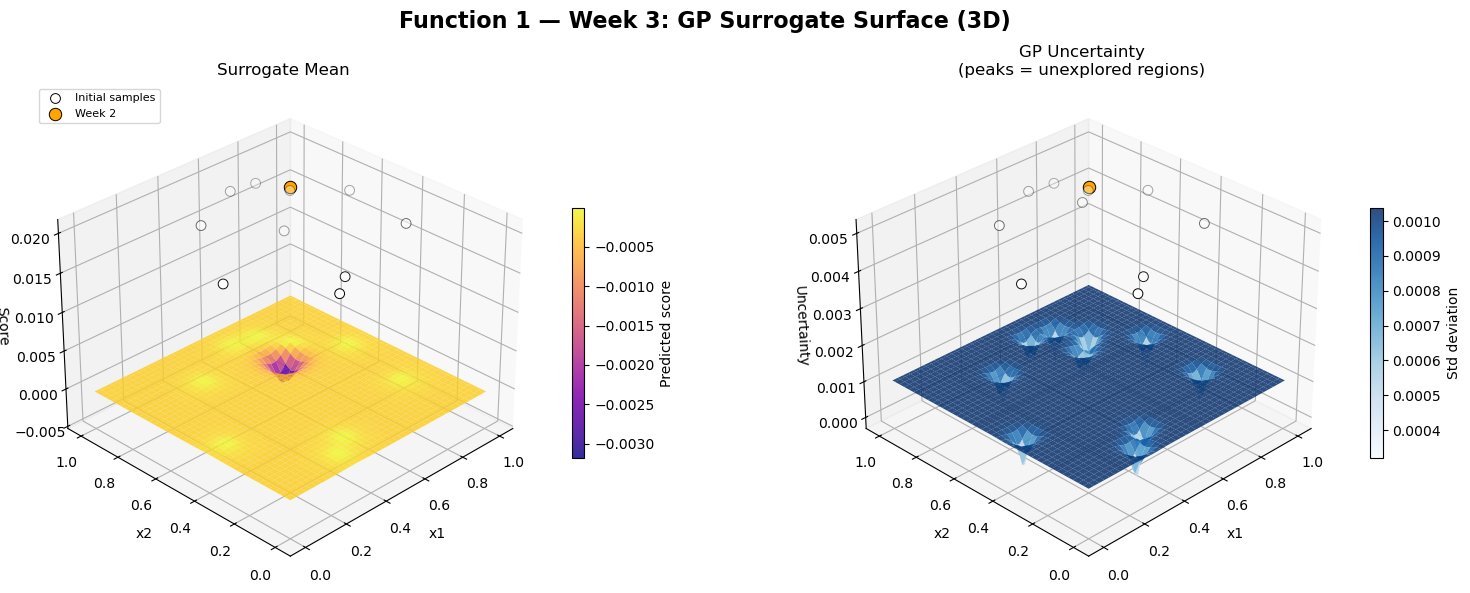

In [5]:
# Build a grid over the input space and evaluate the GP on it purely to visualise the surrogate: 
#     the mean surface shows where the model thinks the response is high, and 
#     the std surface shows where it's still uncertain (unexplored regions), 
#     which is why both are plotted side by side before any query is chosen.

grid_size = 80
xx, yy = np.meshgrid(np.linspace(0, 1, grid_size), np.linspace(0, 1, grid_size))
grid   = np.c_[xx.ravel(), yy.ravel()]

gp_mean, gp_std = gp.predict(grid, return_std=True)
mean_surface = gp_mean.reshape(grid_size, grid_size)
std_surface  = gp_std.reshape(grid_size, grid_size)

fig = plt.figure(figsize=(16, 6))
fig.suptitle('Function 1 — Week 3: GP Surrogate Surface (3D)', fontsize=16, fontweight='bold')


ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(xx, yy, mean_surface, cmap='plasma', alpha=0.85, linewidth=0)
fig.colorbar(surf1, ax=ax1, shrink=0.5, label='Predicted score')


ax1.scatter(initial_inputs[:, 0], initial_inputs[:, 1],
            all_outputs[:10] + 0.02,
            c='white', s=50, edgecolors='black', linewidths=0.7,
            zorder=5, label='Initial samples')

ax1.scatter(week2_input[:, 0], week2_input[:, 1],
            week2_output + 0.02,
            c='orange', s=80, edgecolors='black', linewidths=0.7,
            zorder=6, label='Week 2')

ax1.set_xlabel('x1'); ax1.set_ylabel('x2'); ax1.set_zlabel('Score')
ax1.set_title('Surrogate Mean')
ax1.legend(fontsize=8, loc='upper left')
ax1.view_init(elev=30, azim=225)


ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(xx, yy, std_surface, cmap='Blues', alpha=0.85, linewidth=0)
fig.colorbar(surf2, ax=ax2, shrink=0.5, label='Std deviation')

ax2.scatter(initial_inputs[:, 0], initial_inputs[:, 1],
            np.zeros(10) + 0.005,
            c='white', s=50, edgecolors='black', linewidths=0.7, zorder=5)

ax2.scatter(week2_input[:, 0], week2_input[:, 1],
            [0.005], c='orange', s=80, edgecolors='black', linewidths=0.7, zorder=6)

ax2.set_xlabel('x1'); ax2.set_ylabel('x2'); ax2.set_zlabel('Uncertainty')
ax2.set_title('GP Uncertainty\n(peaks = unexplored regions)')
ax2.view_init(elev=30, azim=225)

plt.tight_layout()
plt.show()

In [6]:
# Select the Week 3 query: score 20k random candidates with Expected Improvement, 
#      keep only the top 15% (the 'plausible' region), 
#      then within that region pick whichever point is farthest from existing samples. 
# EI alone tends to cluster near known good points; 
#      the distance step is added on top to force some spatial diversity instead of pure exploitation.

np.random.seed(42)
candidates = np.random.uniform(0, 1, (20000, 2))

predicted_mean, predicted_std = gp.predict(candidates, return_std=True)
ei_scores    = compute_ei(predicted_mean, predicted_std, all_outputs.max())
min_distance = cdist(candidates, all_inputs).min(axis=1)


ei_threshold    = np.percentile(ei_scores, 85)
plausible       = ei_scores >= ei_threshold


distance_filter = min_distance.copy()
distance_filter[~plausible] = -1

best_index    = np.argmax(distance_filter)
week3_query = candidates[best_index]

print(f"\nWeek 3 Query:   x1={week3_query[0]:.6f}, x2={week3_query[1]:.6f}")
print(f"\nWeek 3 Query formatted: {format_query(week3_query)}")

print(f"Predicted mean: {predicted_mean[best_index]:.3f}")
print(f"Predicted std:  {predicted_std[best_index]:.3f}")
print(f"EI score:       {ei_scores[best_index]:.6f}")
print(f"Distance:       {min_distance[best_index]:.4f}")


Week 3 Query:   x1=0.803076, x2=0.431805

Week 3 Query formatted: 0.803076-0.431805
Predicted mean: -0.000
Predicted std:  0.001
EI score:       0.000000
Distance:       0.1708


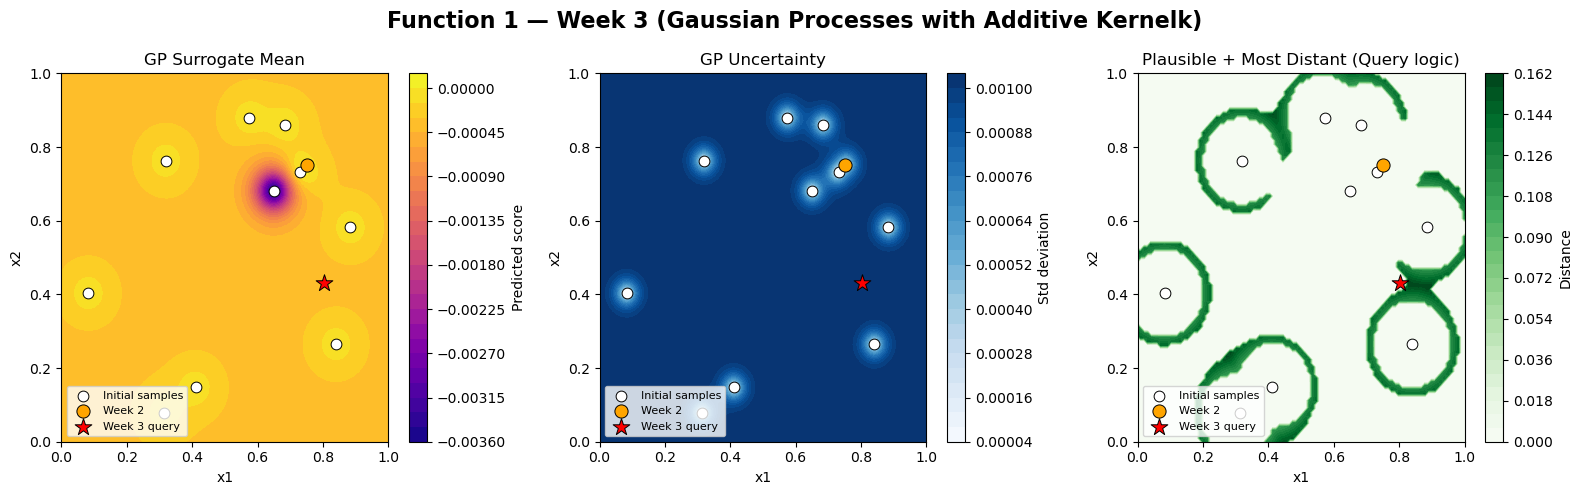

In [7]:
# Re-render the same EI/diversity logic on a finer grid purely for visualisation, 
#      so the chosen Week 3 query can be shown against the mean surface, uncertainty, 
#      and the combined 'plausible + most distant' criterion that actually produced it.

grid_size = 100
xx, yy = np.meshgrid(np.linspace(0, 1, grid_size), np.linspace(0, 1, grid_size))
grid   = np.c_[xx.ravel(), yy.ravel()]

gp_mean, gp_std = gp.predict(grid, return_std=True)
ei_grid      = compute_ei(gp_mean, gp_std, all_outputs.max())
dist_grid    = cdist(grid, all_inputs).min(axis=1)


ei_thresh_grid  = np.percentile(ei_grid, 90)
combined        = np.where(ei_grid >= ei_thresh_grid, dist_grid, 0)


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Function 1 — Week 3 (Gaussian Processes with Additive Kernelk)',
             fontsize=16, fontweight='bold')

panels = [
    (gp_mean.reshape(grid_size, grid_size), 'plasma', 'GP Surrogate Mean', 'Predicted score'),
    (gp_std.reshape(grid_size, grid_size),  'Blues',  'GP Uncertainty', 'Std deviation'),
    (combined.reshape(grid_size, grid_size),'Greens', 'Plausible + Most Distant (Query logic)', 'Distance'),
]

for ax, (surface, cmap, title, cbar_label) in zip(axes, panels):
    im = ax.contourf(xx, yy, surface, levels=30, cmap=cmap)
    plt.colorbar(im, ax=ax, label=cbar_label)

    ax.scatter(initial_inputs[:, 0], initial_inputs[:, 1],
               c='white', s=60, edgecolors='black', linewidths=0.7,
               zorder=5, label='Initial samples')

    ax.scatter(week2_input[:, 0], week2_input[:, 1],
               c='orange', s=90, edgecolors='black', linewidths=0.7,
               zorder=6, label='Week 2')

    ax.scatter(week3_query[0], week3_query[1],
               c='red', s=160, marker='*', edgecolors='black', linewidths=0.7,
               zorder=7, label='Week 3 query')

    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='lower left')

plt.tight_layout()

# Function 2, Unspecified field dataset, 2D array, 10 original samples

**W3 F2 Approach**
- F2 directly reuses F1's pipeline.
- While suitable for early-stage baseline exploration, applying this unadapted model to F2 assumes F2 shares F1’s response surface, length-scale, and variance characteristics.

In [8]:
# Load Function 2's data and append its own Week 2 result. This function reuses the exact F1 pipeline (see the summary table above).

initial_inputs  = np.load('initial_data/function_2/initial_inputs.npy')
initial_outputs = np.load('initial_data/function_2/initial_outputs.npy')

week2_input  = np.array([[1.053349, 0.934354]])
week2_output = np.array([-0.040652])

all_inputs  = np.vstack([initial_inputs, week2_input])
all_outputs = np.hstack([initial_outputs, week2_output])

In [9]:
# Same additive Matern + White kernel GP as Function 1 — 
#     no attempt to adapt the kernel to F2's own response characteristics
#     just a direct reuse of the F1 recipe.

kernel = Matern(nu=2.5) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-3, 1e1))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, normalize_y=True)
gp.fit(all_inputs, all_outputs)

print(f"Learned kernel: {gp.kernel_}")

Learned kernel: Matern(length_scale=0.0974, nu=2.5) + WhiteKernel(noise_level=0.001)


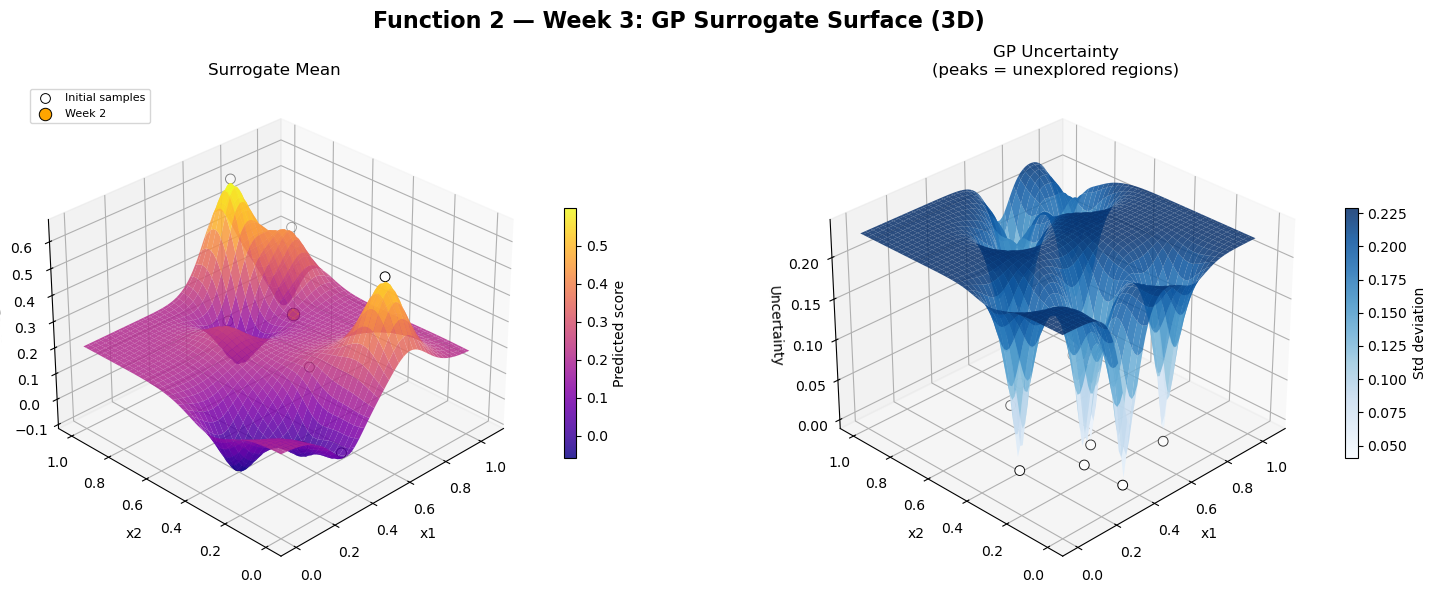

In [10]:
# Same purpose as Function 1's grid/plot step: visualise the surrogate mean and uncertainty
# before trusting it to pick a query.

grid_size = 80
xx, yy = np.meshgrid(np.linspace(0, 1, grid_size), np.linspace(0, 1, grid_size))
grid   = np.c_[xx.ravel(), yy.ravel()]

gp_mean, gp_std = gp.predict(grid, return_std=True)
mean_surface = gp_mean.reshape(grid_size, grid_size)
std_surface  = gp_std.reshape(grid_size, grid_size)

fig = plt.figure(figsize=(16, 6))
fig.suptitle('Function 2 — Week 3: GP Surrogate Surface (3D)', fontsize=16, fontweight='bold')

 
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(xx, yy, mean_surface, cmap='plasma', alpha=0.85, linewidth=0)
fig.colorbar(surf1, ax=ax1, shrink=0.5, label='Predicted score')


ax1.scatter(initial_inputs[:, 0], initial_inputs[:, 1],
            all_outputs[:10] + 0.02,
            c='white', s=50, edgecolors='black', linewidths=0.7,
            zorder=5, label='Initial samples')

ax1.scatter(week2_input[:, 0], week2_input[:, 1],
            week2_output + 0.02,
            c='orange', s=80, edgecolors='black', linewidths=0.7,
            zorder=6, label='Week 2')

ax1.set_xlabel('x1'); ax1.set_ylabel('x2'); ax1.set_zlabel('Score')
ax1.set_title('Surrogate Mean')
ax1.legend(fontsize=8, loc='upper left')
ax1.view_init(elev=30, azim=225)


ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(xx, yy, std_surface, cmap='Blues', alpha=0.85, linewidth=0)
fig.colorbar(surf2, ax=ax2, shrink=0.5, label='Std deviation')

ax2.scatter(initial_inputs[:, 0], initial_inputs[:, 1],
            np.zeros(10) + 0.005,
            c='white', s=50, edgecolors='black', linewidths=0.7, zorder=5)

ax2.scatter(week2_input[:, 0], week2_input[:, 1],
            [0.005], c='orange', s=80, edgecolors='black', linewidths=0.7, zorder=6)

ax2.set_xlabel('x1'); ax2.set_ylabel('x2'); ax2.set_zlabel('Uncertainty')
ax2.set_title('GP Uncertainty\n(peaks = unexplored regions)')
ax2.view_init(elev=30, azim=225)

plt.tight_layout()
plt.show()

In [11]:
# Same EI (top 15%) + farthest-point selection as Function 1, applied to Function 2's GP.

np.random.seed(42)
candidates = np.random.uniform(0, 1, (20000, 2))

predicted_mean, predicted_std = gp.predict(candidates, return_std=True)
ei_scores    = compute_ei(predicted_mean, predicted_std, all_outputs.max())
min_distance = cdist(candidates, all_inputs).min(axis=1)

ei_threshold    = np.percentile(ei_scores, 85)
plausible       = ei_scores >= ei_threshold

distance_filter = min_distance.copy()
distance_filter[~plausible] = -1

best_index    = np.argmax(distance_filter)
week3_query = candidates[best_index]

print(f"\nWeek 3 Query:   x1={week3_query[0]:.6f}, x2={week3_query[1]:.6f}")
print(f"\nWeek 3 Query formatted: {format_query(week3_query)}")

print(f"Predicted mean: {predicted_mean[best_index]:.3f}")
print(f"Predicted std:  {predicted_std[best_index]:.3f}")
print(f"EI score:       {ei_scores[best_index]:.6f}")
print(f"Distance:       {min_distance[best_index]:.4f}")


Week 3 Query:   x1=0.660188, x2=0.329930

Week 3 Query formatted: 0.660188-0.329930
Predicted mean: 0.249
Predicted std:  0.226
EI score:       0.004698
Distance:       0.2060


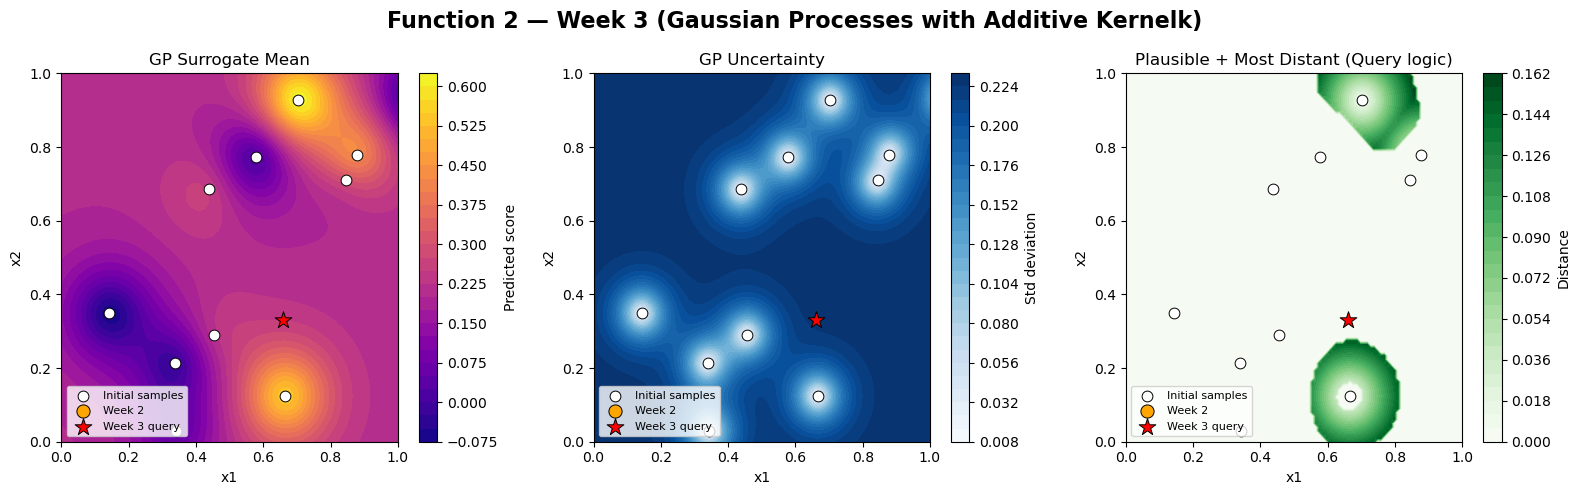

In [12]:
# Same finer-grid visualisation of the EI + diversity query-selection logic,
#      re-plotted for Function 2's surface and chosen point.

grid_size = 100
xx, yy = np.meshgrid(np.linspace(0, 1, grid_size), np.linspace(0, 1, grid_size))
grid   = np.c_[xx.ravel(), yy.ravel()]

gp_mean, gp_std = gp.predict(grid, return_std=True)
ei_grid      = compute_ei(gp_mean, gp_std, all_outputs.max())
dist_grid    = cdist(grid, all_inputs).min(axis=1)


ei_thresh_grid  = np.percentile(ei_grid, 90)
combined        = np.where(ei_grid >= ei_thresh_grid, dist_grid, 0)


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Function 2 — Week 3 (Gaussian Processes with Additive Kernelk)',
             fontsize=16, fontweight='bold')

panels = [
    (gp_mean.reshape(grid_size, grid_size), 'plasma', 'GP Surrogate Mean', 'Predicted score'),
    (gp_std.reshape(grid_size, grid_size),  'Blues',  'GP Uncertainty', 'Std deviation'),
    (combined.reshape(grid_size, grid_size),'Greens', 'Plausible + Most Distant (Query logic)', 'Distance'),
]

for ax, (surface, cmap, title, cbar_label) in zip(axes, panels):
    im = ax.contourf(xx, yy, surface, levels=30, cmap=cmap)
    plt.colorbar(im, ax=ax, label=cbar_label)

    ax.scatter(initial_inputs[:, 0], initial_inputs[:, 1],
               c='white', s=60, edgecolors='black', linewidths=0.7,
               zorder=5, label='Initial samples')

    ax.scatter(week2_input[:, 0], week2_input[:, 1],
               c='orange', s=90, edgecolors='black', linewidths=0.7,
               zorder=6, label='Week 2')

    ax.scatter(week3_query[0], week3_query[1],
               c='red', s=160, marker='*', edgecolors='black', linewidths=0.7,
               zorder=7, label='Week 3 query')

    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='lower left')

plt.tight_layout()

# Function 3, A drug discovery project, 3D array, 15 original samples

**W3 F3 Approach**
- Method: Blends a quadratic polynomial model with a Gaussian Process (GP).
- Purpose: Prevents hyperparameter instability in small samples (~15 observations) by grounding the search in global trends while keeping non-parametric flexibility.
- Weighting: Uses 5-fold cross-validation (R^2) to dynamically favour the polynomial model for smooth quadratic trends or the GP for complex patterns.
- Search Strategy: Combines global random, local perturbation, and targeted directional moves to optimise along suspected variable gradients.

In [13]:
# Load Function 3's data (3D drug-discovery inputs) plus its Week 2 result, and 
# print basic stats so the current best score is visible before modelling starts.

initial_inputs  = np.load('initial_data/function_3/initial_inputs.npy')
initial_outputs = np.load('initial_data/function_3/initial_outputs.npy')

week2_input  = np.array([[0.540087, 0.652622, 0.079307]])
week2_output = np.array([-0.050615])

X  = np.vstack([initial_inputs, week2_input])
Y = np.hstack([initial_outputs, week2_output])

print(f"Total points: {len(Y)}")
print(f"Best result so far: {Y.max():.6f}")
print(f"Output range: [{Y.min():.6f}, {Y.max():.6f}]")

Total points: 16
Best result so far: -0.034835
Output range: [-0.398926, -0.034835]


In [14]:
# Fit a degree-2 polynomial regression as a second, independent surrogate (blended with the GP later).
# Printing the coefficients lets the sign/magnitude of each term be checked, 
#      which is what motivates the 'increase B and C' directed candidates further down.

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Fit linear regression on expanded features
poly_model = LinearRegression()
poly_model.fit(X_poly, Y)

feature_names = ['A', 'B', 'C', 'A*B', 'A*C', 'B*C', 'A²', 'B²', 'C²']
print("\nCoefficients:")
for name, coefficient in zip(feature_names, poly_model.coef_):
    print(f"  {name:6s}: {coefficient:+.4f}")
print(f"  Intercept: {poly_model.intercept_:.4f}")


Coefficients:
  A     : -0.2004
  B     : +0.2382
  C     : +0.7780
  A*B   : -0.1749
  A*C   : +0.5080
  B*C   : +0.5672
  A²    : -0.0955
  B²    : -1.2505
  C²    : -0.5821
  Intercept: -0.2207


In [15]:
# Fit a GP surrogate as the other half of the blend. The high C/B region is checked manually
# here because early exploration suggested that direction looked promising, and this is a
# quick numeric sanity check of the GP's prediction there before committing to it.

kernel = Matern(nu=2.5, length_scale=0.5) + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-4, 1e-1))

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20,
    normalize_y=True,
    random_state=42
)

gp.fit(X, Y)
print(f"Learned kernel: {gp.kernel_}")

print("\n High C/B region check")
test_points = np.array([[0.3, 0.8, 0.9],
                         [0.2, 0.9, 0.95],
                         [0.4, 0.7, 0.85]])
test_mean, test_std = gp.predict(test_points, return_std=True)
for i, p in enumerate(test_points):
    print(f"  {p} → mean: {test_mean[i]:.4f}, std: {test_std[i]:.4f}")

Learned kernel: Matern(length_scale=0.226, nu=2.5) + WhiteKernel(noise_level=0.0001)

 High C/B region check
  [0.3 0.8 0.9] → mean: -0.1587, std: 0.0808
  [0.2  0.9  0.95] → mean: -0.1417, std: 0.0819
  [0.4  0.7  0.85] → mean: -0.1564, std: 0.0791


In [16]:
# Start building the candidate pool with a globally random batch, 
#      so the search isn't restricted to only what the other two candidate strategies below would generate.

np.random.seed(42)

# Random candidates across the full space
random_candidates = np.random.uniform(0, 1, (5000, 3))

### Local candidates

In [17]:
# Add two more candidate sources on top of the random batch: small perturbations around the current best point (local exploitation),
#      and a directed batch that pushes B and C high (a hypothesis from the coefficient signs above).
#  All three pools are stacked together so every candidate — global, local, and hypothesis-driven — gets scored the same way next.


best_point_index = np.argmax(Y)
local_candidates = []

for i in range(2000):
    offset = np.random.normal(0, 0.05, 3)
    candidate = np.clip(X[best_point_index] + offset, 0, 1)
    local_candidates.append(candidate)

directed_candidates = np.random.uniform([0, 0.6, 0.7], [1, 1, 1], (4000, 3))

all_candidates = np.vstack([random_candidates, local_candidates, directed_candidates])

In [18]:
# Score every candidate in the combined pool with both surrogates: GP mean/std -> EI, and the polynomial model's raw prediction. 
#  Both scores are then min-max normalised so they sit on a comparable 0-1 scale and can be blended fairly in the next step.

predicted_mean, predicted_std = gp.predict(all_candidates, return_std=True)

ei_scores = compute_ei(predicted_mean, predicted_std, Y.max(), xi=0.01)

poly_candidates = poly.transform(all_candidates)
poly_predictions = poly_model.predict(poly_candidates)

ei_normalized = (ei_scores - ei_scores.min()) / (ei_scores.max() - ei_scores.min() + 1e-9)
poly_normalized = (poly_predictions - poly_predictions.min()) / (poly_predictions.max() - poly_predictions.min() + 1e-9)

In [19]:
# Decide how much to trust each surrogate by cross-validating both on the real data (5-fold R²)
#        and turning the (clipped-to-nonnegative) scores into blend weights.
#  A model that predicts poorly under CV should contribute less to the final candidate ranking 
#         than one that predicts well — this is what sets that trade-off automatically instead of a fixed 50/50.

cv = KFold(n_splits=5, shuffle=True, random_state=42)
gp_cv_scores = cross_val_score(gp, X, Y, cv=cv, scoring='r2')
poly_cv_scores = cross_val_score(poly_model, X_poly, Y, cv=cv, scoring='r2')

print(gp_cv_scores)

print(poly_cv_scores)

gp_r2 = max(gp_cv_scores.mean(), 0)
poly_r2 = max(poly_cv_scores.mean(), 0)

total = gp_r2 + poly_r2

print(total)

if total == 0:
    gp_weight = 0.5
    poly_weight = 0.5
else:
    gp_weight = gp_r2 / total
    poly_weight = poly_r2 / total

print(f"GP R²: {gp_r2:.3f} → weight: {gp_weight:.2f}")
print(f"Poly R²: {poly_r2:.3f} → weight: {poly_weight:.2f}")

[-2.76798839  0.20905881  0.65900448 -1.4124293  -0.40574213]
[-210.07129625   -1.17510398    0.60630262  -90.68445273   -3.58097237]
0
GP R²: 0.000 → weight: 0.50
Poly R²: 0.000 → weight: 0.50


In [20]:
# Combine the normalised EI and polynomial scores using the CV-derived weights,
#  pick the candidate with the highest blended score as the Week 3 query, and 
# print out each component score so the decision is auditable rather than a black box.

blended_scores = gp_weight * ei_normalized + poly_weight * poly_normalized

print(f"\nBlending: {gp_weight*100:.0f}% GP (EI) + {poly_weight*100:.0f}% Polynomial")

best_candidate_index = np.argmax(blended_scores)
week3_query = all_candidates[best_candidate_index]

print(f"\nWeek 3 Query: {week3_query}")
print(f"\nWeek 3 Query formatted: {format_query(week3_query)}")

print(f"\nPredicted mean: {predicted_mean[best_candidate_index]:.6f}")
print(f"Predicted std:  {predicted_std[best_candidate_index]:.6f}")
print(f"EI score:       {ei_scores[best_candidate_index]:.6f}")
print(f"Poly score:     {poly_predictions[best_candidate_index]:.6f}")
print(f"Blended score:  {blended_scores[best_candidate_index]:.6f}")


Blending: 50% GP (EI) + 50% Polynomial

Week 3 Query: [0.37895591 0.30276761 0.45934601]

Week 3 Query formatted: 0.378956-0.302768-0.459346

Predicted mean: -0.044358
Predicted std:  0.060058
EI score:       0.015453
Poly score:     -0.040719
Blended score:  0.920646


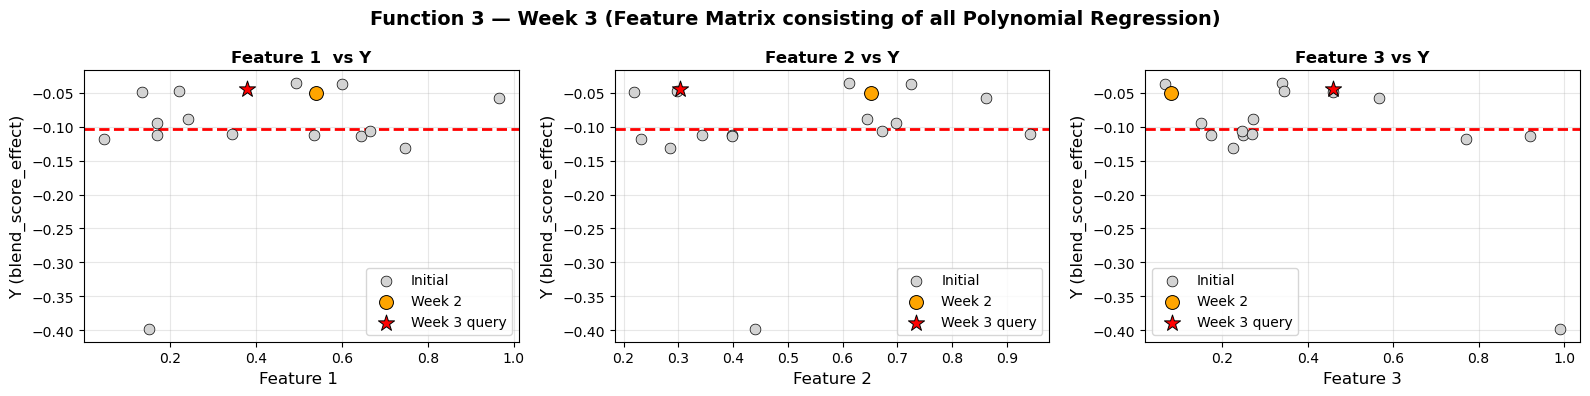

In [21]:
# Plot each input dimension against the output to visually check where the Week 2 point and
#     the newly chosen Week 3 query sit relative to the existing data and the mean response.

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
feature_names = ['Feature 1 ', 'Feature 2', 'Feature 3']

for i, ax in enumerate(axes):

    ax.scatter(X[:15, i], Y[:15], c='lightgray', s=60, edgecolors='black', 
               linewidths=0.5, label='Initial', zorder=3)   
  

    ax.scatter(week2_input[0, i], week2_output[0], c='orange', s=100, 
               edgecolors='black', linewidths=0.7, label='Week 2', zorder=5)
    

    ax.scatter(week3_query[i], predicted_mean[best_candidate_index], 
               c='red', s=150, marker='*', edgecolors='black', 
               linewidths=0.7, label='Week 3 query', zorder=6)
    
    ax.set_xlabel(feature_names[i], fontsize=12)
    ax.set_ylabel('Y (blend_score_effect)', fontsize=12)
    ax.set_title(f'{feature_names[i]} vs Y', fontsize=12, fontweight='bold')
    ax.axhline(Y.mean(), color='red', linestyle='--', linewidth=2)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

fig.suptitle("Function 3 — Week 3 (Feature Matrix consisting of all Polynomial Regression)", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Function 4 — Warehouse business (4D, 30 initial samples)

**W3 F4 Approach**
- Method: Performs 5-fold cross-validation across three Gaussian Process (GP) kernels and
  - uses Expected Improvement (EI) alongside Upper Confidence Bound (UCB).
- Purpose: Mitigates model misspecification in moderate sample sizes (~30 observations)
  - by ensuring the covariance structure fits the data before acquisition.
- Exploration Strategy: Uses UCB with a higher exploration parameter (kappa = 2.0)
  - to prioritise high posterior variance and avoid getting trapped in local optima.

In [22]:
# Load Function 4's data (4D warehouse inputs) plus its Week 2 result, and 
# print the current best so progress is visible.

initial_inputs  = np.load('initial_data/function_4/initial_inputs.npy')
initial_outputs = np.load('initial_data/function_4/initial_outputs.npy')

week2_input  = np.array([[0.149845, 0.155724, 0.46128, 0.344491]])
week2_output = np.array([-7.132125])

all_inputs  = np.vstack([initial_inputs, week2_input])
all_outputs = np.hstack([initial_outputs, week2_output])

print(f"Total points: {all_inputs.shape[0]}")
print(f"Current best: {all_outputs.max():.4f}")

Total points: 31
Current best: -4.0255


In [23]:
# Rather than assuming one kernel form, try three plausible Matern variants 
#     (isotropic, ARD, ARD + noise) and score each with 5-fold CV R², 
# since the right amount of per-dimension flexibility isn't known in advance for a 4D space with only ~30 observations.

candidate_kernels = {
    'Matern(nu=2.5) global':            Matern(length_scale=0.5, length_scale_bounds=(0.001, 10.0), nu=2.5),
    'Matern(nu=2.5) ARD':               Matern(length_scale=[0.5, 0.5, 0.5, 0.5], length_scale_bounds=(0.001, 10.0), nu=2.5),
    'Matern(nu=2.5) ARD + WhiteKernel': Matern(length_scale=[0.5, 0.5, 0.5, 0.5], length_scale_bounds=(0.001, 10.0), nu=2.5) 
    + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-6, 1.0)),
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
kernel_results = {}

for kernel_name, kernel in candidate_kernels.items():
    gaussian_process_candidate = GaussianProcessRegressor(
        kernel=kernel, n_restarts_optimizer=10, alpha=1e-6, normalize_y=True
    )
    cross_validation_scores = cross_val_score(
        gaussian_process_candidate, all_inputs, all_outputs,
        cv=kfold, scoring='r2'
    )
    kernel_results[kernel_name] = {
        'r2_score': cross_validation_scores.mean(),
        'kernel':   kernel
    }
    print(f"{kernel_name}: mean R2 {cross_validation_scores.mean():.4f}")

Matern(nu=2.5) global: mean R2 0.7997
Matern(nu=2.5) ARD: mean R2 0.5232
Matern(nu=2.5) ARD + WhiteKernel: mean R2 0.5084


In [24]:
# Take whichever kernel scored best under CV and refit a fresh GP on the full dataset with it, 
# since the CV loop above only needed the score, not a fitted model to keep.

best_kernel_name = max(kernel_results, key=lambda k: kernel_results[k]['r2_score'])
best_kernel      = kernel_results[best_kernel_name]['kernel']
print(f"\nBest kernel: {best_kernel_name}")

gaussian_process = GaussianProcessRegressor(
    kernel=best_kernel, n_restarts_optimizer=15, alpha=1e-6, normalize_y=True
)
gaussian_process.fit(all_inputs, all_outputs)
print(f"Fitted kernel: {gaussian_process.kernel_}")


Best kernel: Matern(nu=2.5) global
Fitted kernel: Matern(length_scale=0.592, nu=2.5)


In [25]:
# Score 10k random candidates with Upper Confidence Bound (kappa=2.0, favoring exploration) instead of EI,
#     and print the winning point along with its distance from the Week 2 query so
#     it's clear the new suggestion isn't just repeating last week's location.

np.random.seed(42)
candidates = np.random.uniform(0, 1, (10000, 4))

# compute ucb scores across all candidates
predicted_means, predicted_stds = gaussian_process.predict(candidates, return_std=True)
kappa = 2.0
upper_confidence_bound_scores = predicted_means + kappa * predicted_stds

best_candidate_index = np.argmax(upper_confidence_bound_scores)
week3_query          = candidates[best_candidate_index]

print(f"\nWeek 3 Query: {week3_query.round(6).tolist()}")
print(f"\nWeek 3 Query formatted: {format_query(week3_query)}")
print(f"Predicted mean: {predicted_means[best_candidate_index]:.4f}")
print(f"Predicted std:  {predicted_stds[best_candidate_index]:.4f}")
print(f"UCB score:      {upper_confidence_bound_scores[best_candidate_index]:.4f}")
print(f"Distance from Week 2: {np.linalg.norm(week3_query - week2_input[0]):.4f}")


Week 3 Query: [0.330258, 0.414348, 0.433728, 0.411341]

Week 3 Query formatted: 0.330258-0.414348-0.433728-0.411341
Predicted mean: -1.0708
Predicted std:  1.7981
UCB score:      2.5255
Distance from Week 2: 0.3235


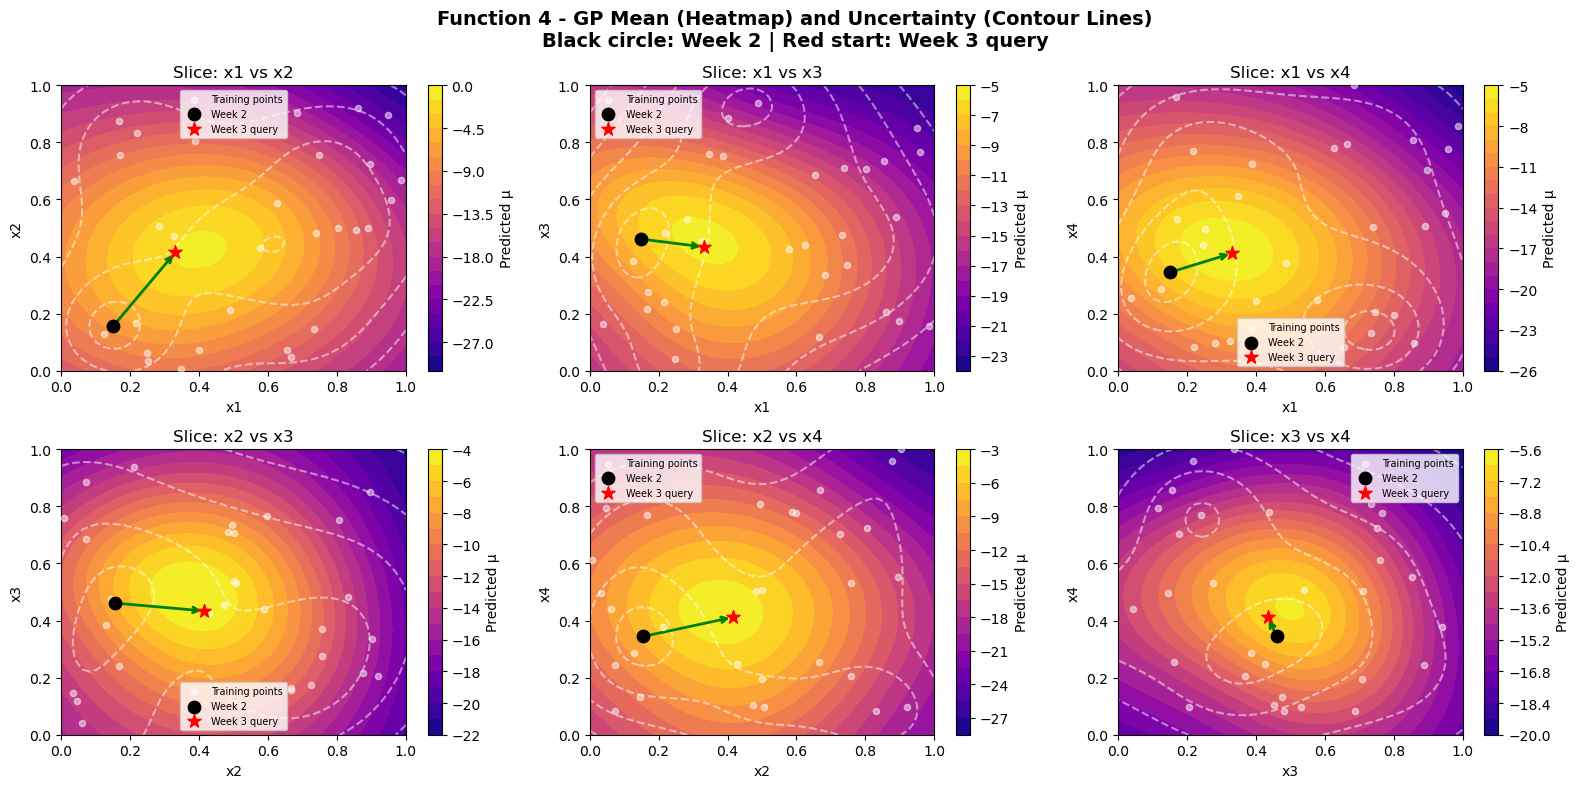

In [26]:
# Visualise the fitted GP as 2D slices through every pair of dimensions 
# (holding the other two fixed at the Week 2 point), so the mean/uncertainty structure that produced 
# the chosen UCB query can be inspected dimension-pair by dimension-pair instead of only as a single number.

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

dimension_pairs = list(itertools.combinations(range(4), 2))
dimension_names = ['x1', 'x2', 'x3', 'x4']
week2_point = week2_input[0]
week3_point = week3_query

for plot_index, (dim_a, dim_b) in enumerate(dimension_pairs):
    ax = axes[plot_index]
    
    grid_values = np.linspace(0, 1, 50)
    grid_a, grid_b = np.meshgrid(grid_values, grid_values)
    
    grid_candidates = np.tile(week2_point, (50 * 50, 1))
    grid_candidates[:, dim_a] = grid_a.ravel()
    grid_candidates[:, dim_b] = grid_b.ravel()
    
    grid_means, grid_stds = gaussian_process.predict(grid_candidates, return_std=True)
    grid_means_2d = grid_means.reshape(50, 50)
    grid_stds_2d  = grid_stds.reshape(50, 50)
    
    mean_plot = ax.contourf(grid_a, grid_b, grid_means_2d, levels=20, cmap='plasma')
    ax.contour(grid_a, grid_b, grid_stds_2d, levels=5, 
               colors='white', alpha=0.5, linestyles='dashed')
    plt.colorbar(mean_plot, ax=ax, label='Predicted μ')
    

    ax.scatter(all_inputs[:, dim_a], all_inputs[:, dim_b],
               color='white', s=20, alpha=0.5, zorder=4, label='Training points')
    
    ax.scatter(week2_point[dim_a], week2_point[dim_b],
               color='k', s=80, zorder=6, marker='o', label='Week 2')
    

    ax.scatter(week3_point[dim_a], week3_point[dim_b],
               color='red', s=100, zorder=6, marker='*', label='Week 3 query')
    
    ax.annotate('', 
                xy=(week3_point[dim_a], week3_point[dim_b]),
                xytext=(week2_point[dim_a], week2_point[dim_b]),
                arrowprops=dict(arrowstyle='->', color='green', lw=2))
    
    ax.set_xlabel(dimension_names[dim_a])
    ax.set_ylabel(dimension_names[dim_b])
    ax.set_title(f'Slice: {dimension_names[dim_a]} vs {dimension_names[dim_b]}')
    ax.legend(fontsize=7)

plt.suptitle('Function 4 - GP Mean (Heatmap) and Uncertainty (Contour Lines)\nBlack circle: Week 2 | Red start: Week 3 query', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Function 5, A chemical process in a factory, 4D array, 20 original samples

**W3 F5 Approach**
- Method: Pre-filters a dense candidate pool with Support Vector Regression (SVR),
  - then evaluates top candidates using low-exploration Expected Improvement (EI, $\xi = 0.005$).
- Purpose: Reduces the high computational cost of full Gaussian Process (GP) evaluation across large candidate spaces.
- Exploration Strategy: Narrows the top 3,000 candidates around the current best solution (incumbent) to aggressively exploit high-performing neighbourhoods.

In [27]:
# Load Function 5's data (4D chemical-process inputs) plus its Week 2 result, and print the current best.

initial_inputs  = np.load('initial_data/function_5/initial_inputs.npy')
initial_outputs = np.load('initial_data/function_5/initial_outputs.npy')

week2_input  = np.array([[0.417098, 0.75603, 0.129487, 1.149173]])
week2_output = np.array([1829.809875])

all_inputs  = np.vstack([initial_inputs, week2_input])
all_outputs = np.hstack([initial_outputs, week2_output])

print(f"Total points: {len(all_outputs)}, best: {all_outputs.max():.2f}")

Total points: 21, best: 1829.81


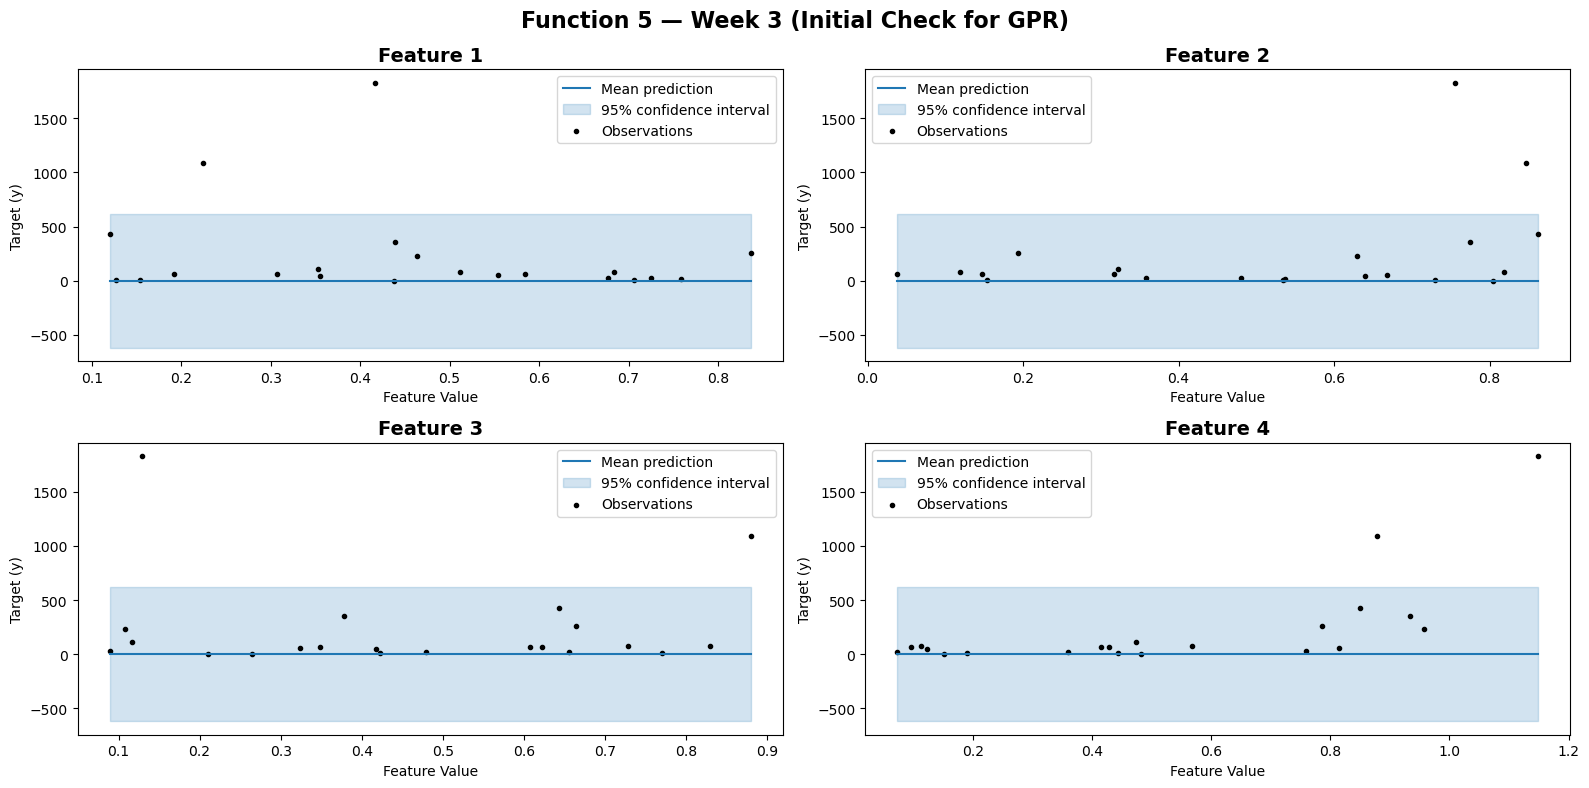

In [28]:
# Fit a quick baseline GP (plain RBF kernel, no tuning) purely as a sanity check: 
# the 1D partial-dependence plots let each feature's effect be eyeballed 
# before committing to the more carefully tuned surrogates used later for the actual query.

X_train = all_inputs
y_train = all_outputs

kernel = 1.0 * RBF(length_scale=1.0)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5)
gpr.fit(X_train, y_train)

feature_names = ['Feature 1', 'Feature 2', 'Feature 3', 'Feature 4']

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

fig.suptitle("Function 5 — Week 3 (Initial Check for GPR)", fontsize=16, fontweight='bold')

median_features = np.median(X_train, axis=0)

for i in range(4):
    x_test_1d = np.linspace(X_train[:, i].min(), X_train[:, i].max(), 100)
    
    X_test = np.tile(median_features, (100, 1))
    X_test[:, i] = x_test_1d
    
    mean_prediction, std_prediction = gpr.predict(X_test, return_std=True)
    
    ax = axes[i]
    ax.plot(x_test_1d, mean_prediction, color='tab:blue', label='Mean prediction')
    ax.fill_between(
        x_test_1d,
        mean_prediction - 1.96 * std_prediction,
        mean_prediction + 1.96 * std_prediction,
        color='tab:blue',
        alpha=0.2,
        label='95% confidence interval'
    )
    
    mask = (np.abs(X_train[:, :8] - median_features) < 1.0).all(axis=1) 
    ax.scatter(X_train[mask, i], y_train[mask], c='k', marker='.', label='Observations')
    
    ax.set_title(feature_names[i], fontsize=14, fontweight='bold')
    ax.set_xlabel('Feature Value')
    ax.set_ylabel('Target (y)')
    ax.legend(loc='best')

plt.tight_layout()
plt.show()

# Support Vector Regressor (SVR) with a Radial Basis Function (RBF) kernel 

It represents a highly flexible, non-linear regression model with strict penalty and tolerance setting

In [29]:
# Standardise inputs and outputs before fitting SVR, 
# since SVR with an RBF kernel is sensitive to feature scale in a way the GP (fit on raw units elsewhere) is not.

input_scaler  = StandardScaler()
output_scaler = StandardScaler()
X_scaled = input_scaler.fit_transform(all_inputs)
Y_scaled = output_scaler.fit_transform(all_outputs.reshape(-1, 1)).ravel()

### Plotting SVR with 4 features

Plotting Actual vs. Predicted ValuesThis is the most common method to visually assess model performance. 

If your SVR model is highly accurate, the points will fall tightly along a 45-degree diagonal line.

X-axis: Actual (True) target valuesY-axis: Predicted values from your 4-feature SVR model

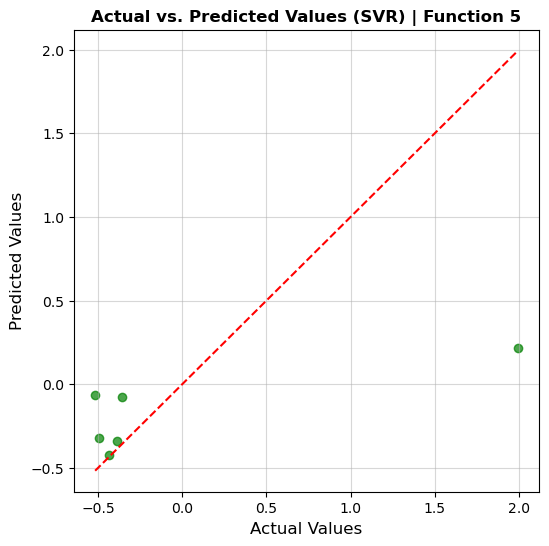

In [30]:
# Hold out a test split, fit SVR on the scaled training data, 
# and plot predicted vs. actual on the held-out points
#  as a visual accuracy check — points hugging the diagonal indicate 
#    the SVR surrogate is trustworthy enough to help filter candidates later.

X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y_scaled, test_size=0.25, random_state=42)

regressor = SVR(kernel='rbf') 
regressor.fit(X_train, y_train)
y_pred = regressor.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color='green', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('Actual vs. Predicted Values (SVR) | Function 5', fontsize=12, fontweight='bold')
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.grid(True, alpha=0.5)
plt.show()

# Regression

In [31]:
# Fit a simple linear regression to read off the sign of each input's effect on the output.
# Those signs are what the directional candidate generation below uses to decide which way to nudge each dimension.

linear_model = LinearRegression()
linear_model.fit(all_inputs, all_outputs)

print("Linear regression coefficients:")
for i, coef in enumerate(linear_model.coef_):
    print(f"  x{i+1}: {coef:.2f}")

Linear regression coefficients:
  x1: -323.44
  x2: 300.06
  x3: 200.02
  x4: 827.43


Support Vector Regressor (SVR) with a Radial Basis Function (RBF) kernel using the scikit-learn library. 

It represents a highly flexible, non-linear regression model with strict penalty and tolerance setting.

In [32]:
# Fit the two surrogates that actually drive the Week 3 decision for this function: 
# an SVR (used to cheaply pre-filter a large candidate pool) and a GP (used for EI on the survivors).
# Splitting the work this way keeps the expensive GP from having to score every candidate.

svr_model = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svr_model.fit(X_scaled, Y_scaled)

kernel = ConstantKernel(1.0, (0.001, 1000)) * Matern(length_scale=0.2, nu=2.5)
gp_model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25, alpha=1e-6, normalize_y=True)
gp_model.fit(all_inputs, all_outputs)

,kernel,"1**2 * Matern...e=0.2, nu=2.5)"
,alpha,1e-06
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,25
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,1**2
,kernel__k2,"Matern(length...e=0.2, nu=2.5)"
,kernel__k1__constant_value,1.0


In [33]:
# Build the candidate pool entirely around the current best point: 
# dense local perturbations for fine-grained exploitation, 
# plus a directional batch that nudges each dimension using the linear-regression sign from above.
# Nothing here samples far from the incumbent, which is why this pipeline is strongly exploitation-biased
#  (see limitations in the summary table).

best_point = all_inputs[np.argmax(all_outputs)]
np.random.seed(42)

local_candidates = []
for _ in range(8000):
    candidate = best_point + np.random.normal(0, 0.05, 4)
    candidate = np.clip(candidate, 0, 0.9999)
    local_candidates.append(candidate)

directional_candidates = []
for _ in range(2000):
    candidate = best_point.copy()
    for dimension in range(4):
        if linear_model.coef_[dimension] > 0:
            candidate[dimension] = min(candidate[dimension] + abs(np.random.normal(0, 0.05)), 1.0)
        else:
            candidate[dimension] = max(candidate[dimension] + np.random.normal(0, 0.02), 0.0)
    directional_candidates.append(candidate)

candidates = np.vstack([local_candidates, directional_candidates])

In [34]:
# Use the cheap SVR model to rank all candidates and keep only the top 3000, 
# so the expensive GP+EI step below only has to run on a pre-filtered shortlist.

scaled_candidates = input_scaler.transform(candidates)
svr_predictions = output_scaler.inverse_transform(
    svr_model.predict(scaled_candidates).reshape(-1, 1)
).ravel()

top_indices = np.argsort(svr_predictions)[-3000:]
filtered_candidates = candidates[top_indices]

In [35]:
# Score the SVR-filtered shortlist with the GP and Expected Improvement, 
# pick the top-scoring point as the Week 3 query, and print the GP/SVR/EI values behind that choice.

mean, std = gp_model.predict(filtered_candidates, return_std=True)
ei_scores = compute_ei(mean, std, all_outputs.max(), xi=0.005)

best_index = np.argmax(ei_scores)
query = filtered_candidates[best_index]

print(f"\nWeek 3 query: {query}")
print(f"\nWeek 3 Query formatted: {format_query(query)}")
print(f"GP mean: {mean[best_index]:.2f}")
print(f"GP std: {std[best_index]:.2f}")
print(f"SVR prediction: {svr_predictions[top_indices[best_index]]:.2f}")
print(f"Expected Improvement score: {ei_scores[best_index]:.6f}")


Week 3 query: [0.38663303 0.82184276 0.12798983 0.9999    ]

Week 3 Query formatted: 0.386633-0.821843-0.127990-0.999900
GP mean: 869.86
GP std: 373.25
SVR prediction: 1216.58
Expected Improvement score: 0.597349


# Function 6, A cake recipe, 5D array, 20 original samples

**W3 F6 Approach**
- Method: Uses Gaussian Process regression with Automatic Relevance Determination (ARD) kernels and Expected Improvement ($\xi = 0.05$).
- Purpose: Handles anisotropic sensitivity in higher dimensions (5D) where standard isotropic kernels fail due to inputs acting on different scales.
- Exploration Strategy: Combines Latin Hypercube Sampling (LHS), random points, and local perturbations around the top five candidates to balance global coverage with local exploitation under higher exploration ($\xi = 0.05$).

In [36]:
# Load Function 6's data (5D cake-recipe inputs) plus its Week 2 result, and 
# print basic stats — output range and current best are shown since the goal here is 0 rather than a max.

initial_inputs  = np.load('initial_data/function_6/initial_inputs.npy')
initial_outputs = np.load('initial_data/function_6/initial_outputs.npy')

week2_input  = np.array([[0.939456, 0.643603, 0.531941, 1.03164, 0.012391]])
week2_output = np.array([-1.241946])

all_inputs  = np.vstack([initial_inputs, week2_input])
all_outputs = np.hstack([initial_outputs, week2_output])

print(f"Total observations : {all_inputs.shape[0]}")
print(f"Output range       : [{all_outputs.min():.3f}, {all_outputs.max():.3f}]")
print(f"Current best       : {all_outputs.max():.3f}  (goal: 0)")

Total observations : 21
Output range       : [-2.571, -0.714]
Current best       : -0.714  (goal: 0)


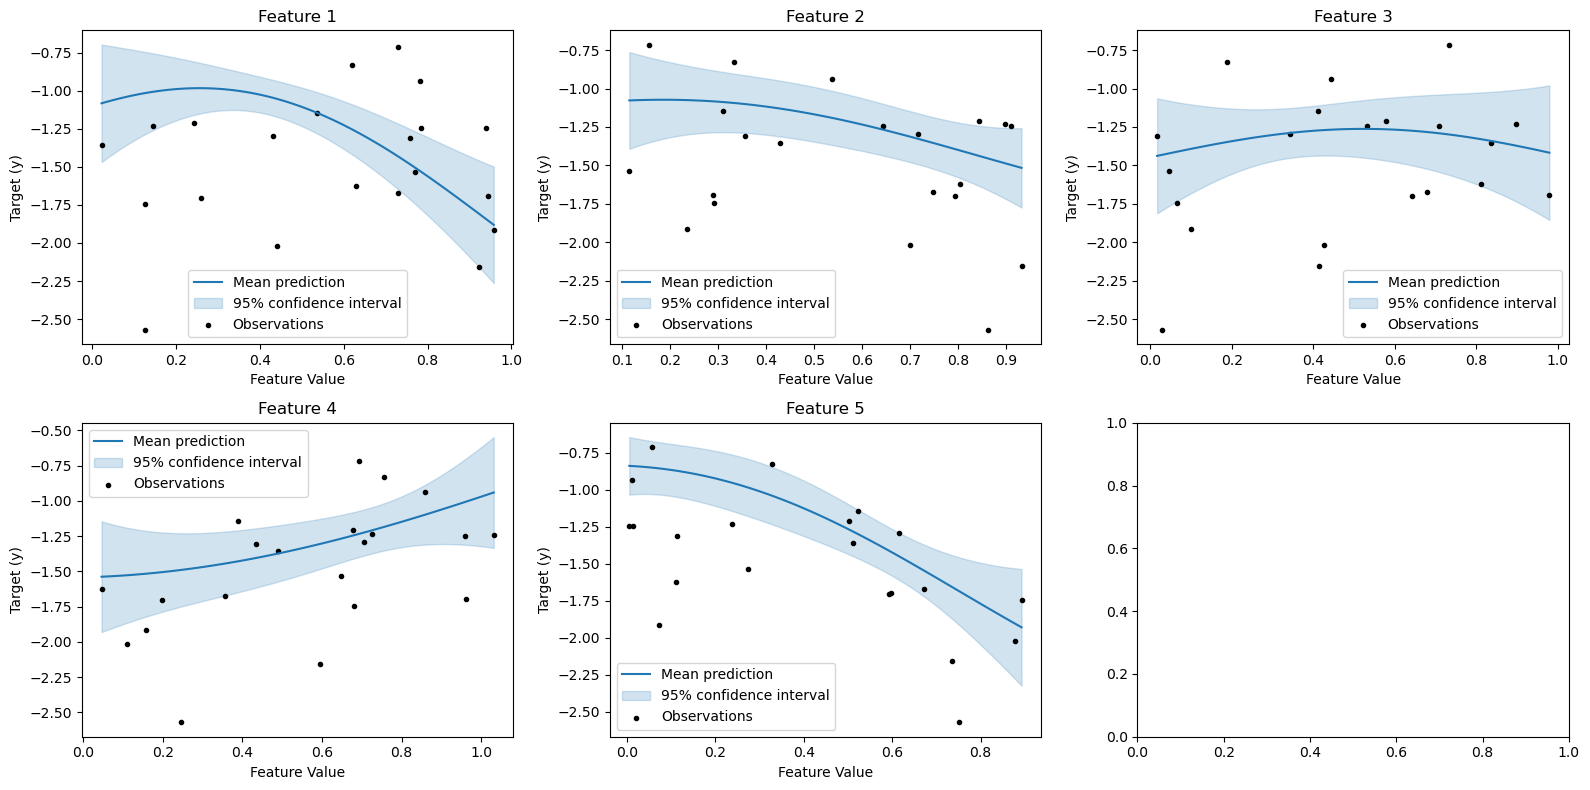

In [37]:
# Fit a quick baseline GP (plain RBF, no per-dimension tuning) purely 
# to sanity-check each ingredient's marginal effect via partial-dependence plots
# before fitting the real ARD surrogate below.

X_train = all_inputs
y_train = all_outputs

kernel = 1.0 * RBF(length_scale=1.0)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5)
gpr.fit(X_train, y_train)

feature_names = ['Feature 1', 'Feature 2', 'Feature 3', 'Feature 4', 
                 'Feature 5',]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

median_features = np.median(X_train, axis=0)

for i in range(5):

    x_test_1d = np.linspace(X_train[:, i].min(), X_train[:, i].max(), 100)
    

    X_test = np.tile(median_features, (100, 1))
    X_test[:, i] = x_test_1d
    
    mean_prediction, std_prediction = gpr.predict(X_test, return_std=True)
    
    ax = axes[i]
    ax.plot(x_test_1d, mean_prediction, color='tab:blue', label='Mean prediction')
    ax.fill_between(
        x_test_1d,
        mean_prediction - 1.96 * std_prediction,
        mean_prediction + 1.96 * std_prediction,
        color='tab:blue',
        alpha=0.2,
        label='95% confidence interval'
    )
    
    mask = (np.abs(X_train[:, :8] - median_features) < 1.0).all(axis=1) 
    ax.scatter(X_train[mask, i], y_train[mask], c='k', marker='.', label='Observations')
    
    ax.set_title(feature_names[i])
    ax.set_xlabel('Feature Value')
    ax.set_ylabel('Target (y)')
    ax.legend(loc='best')

plt.tight_layout()
plt.show()

In [38]:
# Fit the production surrogate with an ARD Matern kernel — a separate length-scale per  ingredient — 
# since ingredients likely differ in how sensitive the recipe score is to them.
# Printing the fitted length-scales shows which ingredients the GP learned matter most
# (short length-scale = output changes quickly with that ingredient).

kernel = ConstantKernel(1.0, (0.001, 1000)) * Matern(
    length_scale       = [1.0, 1.0, 1.0, 1.0, 1.0],    # one per ingredient
    length_scale_bounds= (0.05, 5.0),                   
    nu                 = 2.5                           
)

gp = GaussianProcessRegressor(
    kernel             = kernel,
    n_restarts_optimizer = 25,    
    alpha              = 0.00001, 
    normalize_y        = True     
)

gp.fit(all_inputs, all_outputs)

fitted_length_scales = np.round(gp.kernel_.k2.length_scale, 3)
print(f"\nFitted ARD length scales per ingredient:")
ingredient_names = ["x1 (ingredient 1)", "x2 (ingredient 2)", "x3 (ingredient 3)", "x4 (ingredient 4)", "x5 (ingredient 5)"]
for name, ls in zip(ingredient_names, fitted_length_scales):
    print(f"  {name}: {ls:.3f}")


Fitted ARD length scales per ingredient:
  x1 (ingredient 1): 0.692
  x2 (ingredient 2): 1.015
  x3 (ingredient 3): 1.420
  x4 (ingredient 4): 1.656
  x5 (ingredient 5): 0.986


In [39]:
# Build a mixed candidate pool from three complementary sources: uniform random (global coverage), 
# Latin Hypercube samples (even space-filling), and perturbations around the top 5 recipes so far (local exploitation). 
# Mixing strategies here are what give this function's search both breadth and depth instead of relying on just one.

np.random.seed(42)
random_candidates = np.random.uniform(0, 1, (10000, 5))

sampler       = LatinHypercube(d=5, seed=42)
lhs_candidates = sampler.random(n=5000)

near_best = []
top_indices = np.argsort(all_outputs)[-5:][::-1]
for index in top_indices:
    for _ in range(400):
        random_noise = np.random.normal(0, 0.07, 5)
        candidate    = np.clip(all_inputs[index] + random_noise, 0, 1)
        near_best.append(candidate)

candidates = np.vstack([
    random_candidates,
    lhs_candidates,
    np.array(near_best)
])
print(f"\nTotal candidates evaluated: {candidates.shape[0]}")


Total candidates evaluated: 17000


In [40]:
# Score the combined pool with Expected Improvement (using a relatively large xi=0.05, 
# which biases toward more exploratory picks) and select/print the winning candidate as the Week 3  query.

mu, sigma = gp.predict(candidates, return_std=True)
ei = compute_ei(mu, sigma, all_outputs.max(), xi=0.05)

best_index = np.argmax(ei)
query = candidates[best_index]

print(f"\nWeek 3 Query       : {query}")
print(f"\nWeek 3 Query formatted: {format_query(query)}")
print(f"Predicted mean (μ) : {mu[best_index]:.4f}")
print(f"Predicted std  (σ) : {sigma[best_index]:.4f}")
print(f"Expected Improvement: {ei[best_index]:.6f}")


Week 3 Query       : [0.46321947 0.30640409 0.63523959 0.9998441  0.0156715 ]

Week 3 Query formatted: 0.463219-0.306404-0.635240-0.999844-0.015672
Predicted mean (μ) : -0.2758
Predicted std  (σ) : 0.2649
Expected Improvement: 0.396866


# Function 7, Unspecified field, 6D array, 30 original samples

**W3 F7 Approach**
- Method: Uses Random Forest feature selection via SHAP values, a $\text{log1p}$ target transformation, and 500 L-BFGS-B restarts for acquisition optimisation.
- Purpose: Combats the curse of dimensionality and handles skewed target distributions by focusing the search on the most influential subspace and stabilising variance.
- Optimisation Strategy: Restricts continuous local acquisition optimisation (via L-BFGS-B) to the high-importance subspace to efficiently locate local optima.

In [41]:
# Load Function 7's data (6D, unspecified field) plus its Week 2 result, and 
# print summary stats including which input currently gives the best output.

initial_inputs  = np.load('initial_data/function_7/initial_inputs.npy')
initial_outputs = np.load('initial_data/function_7/initial_outputs.npy')

week2_input  = np.array([[0.079933, 0.633654, 0.734486, 0.864915, 0.103811, 0.933346, ]])
week2_output = np.array([0.592794])

all_inputs  = np.vstack([initial_inputs, week2_input])
all_outputs = np.hstack([initial_outputs, week2_output])

feature_names = [f"SHAP{i+1}" for i in range(6)]

print(f"Total data points : {len(all_outputs)}")
print(f"Output range      : [{all_outputs.min():.3f}, {all_outputs.max():.3f}]")
print(f"Current best      : {all_outputs.max():.4f}")
print(f"Best input        : {all_inputs[np.argmax(all_outputs)]}")

Total data points : 31
Output range      : [0.003, 1.365]
Current best      : 1.3650
Best input        : [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]


### Step 1: RF + SHAP

In [42]:
# Step 1 end-to-end: train a Random Forest to get feature importances (which dimensions matter), 
# run SHAP on it to double-check those importances, then compare the top-25% performers' average input
# against the dataset average to learn which direction (high/low) each dimension should be pushed. 
# This is what defines the reduced search region in Step 2.

print("Step 1: Random Forest + SHAP")
random_forest = RandomForestRegressor(n_estimators=200, random_state=42)
random_forest.fit(all_inputs, all_outputs)

print("\nRF Feature Importance:")
for name, importance in zip(feature_names, random_forest.feature_importances_):
    print(f"  {name}: {importance:.3f}")

explainer = shap.TreeExplainer(random_forest)
shap_values = explainer.shap_values(all_inputs)

top_performers_mask = all_outputs >= np.percentile(all_outputs, 75)
mean_abs_shap = np.abs(shap_values).mean(axis=0)

print("\nMean absolute SHAP values (overall influence):")
for name, value in zip(feature_names, mean_abs_shap):
    print(f"  {name}: {value:.3f}")

dataset_mean = all_inputs.mean(axis=0)
top_mean     = all_inputs[top_performers_mask].mean(axis=0)
push_high    = top_mean > dataset_mean

print(f"\nFeature direction (top 25% mean vs dataset mean):")
for name, top, avg, high in zip(feature_names, top_mean, dataset_mean, push_high):
    direction = "high" if high else "low"
    print(f"  {name}: top mean {top:.3f} vs dataset mean {avg:.3f}  ->  push {direction}")

Step 1: Random Forest + SHAP

RF Feature Importance:
  SHAP1: 0.375
  SHAP2: 0.119
  SHAP3: 0.078
  SHAP4: 0.033
  SHAP5: 0.221
  SHAP6: 0.174

Mean absolute SHAP values (overall influence):
  SHAP1: 0.060
  SHAP2: 0.035
  SHAP3: 0.026
  SHAP4: 0.008
  SHAP5: 0.067
  SHAP6: 0.061

Feature direction (top 25% mean vs dataset mean):
  SHAP1: top mean 0.278 vs dataset mean 0.497  ->  push low
  SHAP2: top mean 0.471 vs dataset mean 0.403  ->  push high
  SHAP3: top mean 0.559 vs dataset mean 0.401  ->  push high
  SHAP4: top mean 0.591 vs dataset mean 0.524  ->  push high
  SHAP5: top mean 0.233 vs dataset mean 0.455  ->  push low
  SHAP6: top mean 0.695 vs dataset mean 0.499  ->  push high


### Step 2: Subspace definition

In [43]:
# Turn Step 1's importances/directions into an actual subspace: important dimensions get 
#        a narrow window (the RF is confident about them), unimportant ones get a wide window, and 
#       the direction result decides which side of [0,1] that window sits on. 
# Confining the search to this subspace is what makes this function's strategy exploitation-heavy — 
# see the table's limitation about being unable to reach optima outside a mis-estimated subspace.

print("Step 2: Subspace Definition")
constraint_width = 1.0 - random_forest.feature_importances_

subspace_lower = np.where(push_high, 1.0 - constraint_width, 0.02)
subspace_upper = np.where(push_high, 1.0, constraint_width)
subspace_lower = np.clip(subspace_lower, 0, 1)
subspace_upper = np.clip(subspace_upper, 0, 1)

print("\nSubspace bounds (RF importance controls width, direction controls placement):")
for name, low, high, importance, direction in zip(
    feature_names, subspace_lower, subspace_upper,
    random_forest.feature_importances_, push_high
):
    label = "high" if direction else "low"
    print(f"  {name}: [{low:.3f}, {high:.3f}]  (importance {importance:.3f}, push {label})")

Step 2: Subspace Definition

Subspace bounds (RF importance controls width, direction controls placement):
  SHAP1: [0.020, 0.625]  (importance 0.375, push low)
  SHAP2: [0.119, 1.000]  (importance 0.119, push high)
  SHAP3: [0.078, 1.000]  (importance 0.078, push high)
  SHAP4: [0.033, 1.000]  (importance 0.033, push high)
  SHAP5: [0.020, 0.779]  (importance 0.221, push low)
  SHAP6: [0.174, 1.000]  (importance 0.174, push high)


### Step 3: GP with EI inside the subspace

In [44]:
# Step 3 end-to-end: fit a GP on log1p-transformed outputs (stabilises variance for a skewed response), 
# define a negative-EI objective compared in the same log scale the GP was fit on,
# then run 500 random-start L-BFGS-B optimisations confined to the Step-2 subspace and keep the best result found. 
# Multi-start is used because EI is non-convex and a single local optimiser run could easily land in a weak local optimum.


print("Step 3: GP with Expected Improvement")

kernel = ConstantKernel(1.0, (0.01, 10.0)) * Matern(
    length_scale=[0.3] * 6,
    length_scale_bounds=(0.05, 5.0),
    nu=2.5,
)
gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20,
    normalize_y=True,
)
gp.fit(all_inputs, np.log1p(all_outputs))

def negative_ei(candidate, gp, best_output, xi=0.01):
    candidate = candidate.reshape(1, -1)
    mean, std = gp.predict(candidate, return_std=True)
    # Comparison must be in log scale since the GP was fitted on log1p outputs
    best_log = np.log1p(best_output)
    if std[0] == 0:
        return 0.0
    improvement = mean - best_log - xi
    z = improvement / std
    ei = improvement * norm.cdf(z) + std * norm.pdf(z)
    return -ei[0]  # negative because scipy minimises

best_output_so_far = all_outputs.max()
bounds = list(zip(subspace_lower, subspace_upper))

best_ei_value = np.inf
best_candidate = None

np.random.seed(42)
for _ in range(500):
    start = np.array([np.random.uniform(low, high) for low, high in bounds])
    result = minimize(
        negative_ei,
        start,
        args=(gp, best_output_so_far),
        bounds=bounds,
        method="L-BFGS-B",
    )
    if result.fun < best_ei_value:
        best_ei_value = result.fun
        best_candidate = result.x

predicted_mean, predicted_std = gp.predict(best_candidate.reshape(1, -1), return_std=True)
predicted_y = np.expm1(predicted_mean[0])


print(f"\nWeek 3 suggested query: {best_candidate}")
print(f"\nWeek 3 Query formatted: {format_query(best_candidate)}")

print(f"\nGP predicted Y (original scale) : {predicted_y:.4f}")
print(f"GP uncertainty (log scale std)  : {predicted_std[0]:.4f}")

Step 3: GP with Expected Improvement

Week 3 suggested query: [0.02       0.2292708  0.47852636 0.24745667 0.36599869 0.73738313]

Week 3 Query formatted: 0.020000-0.229271-0.478526-0.247457-0.365999-0.737383

GP predicted Y (original scale) : 1.3669
GP uncertainty (log scale std)  : 0.0661


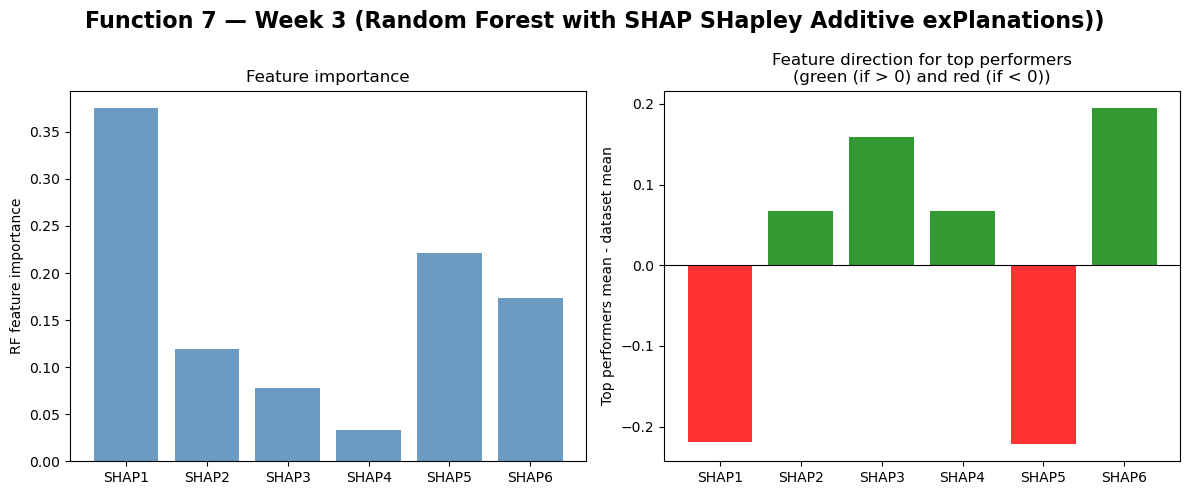

In [45]:
# Plot RF feature importance alongside each feature's push direction, 
# so the reasoning behind the subspace used to find the Week 3 query is visible at a glance rather than just numbers.

figure, axes = plt.subplots(1, 2, figsize=(12, 5))
figure.suptitle("Function 7 — Week 3 (Random Forest with SHAP SHapley Additive exPlanations))", fontsize=16, fontweight='bold')

x_positions = np.arange(6)
axes[0].bar(x_positions, random_forest.feature_importances_, color="steelblue", alpha=0.8)
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(feature_names)
axes[0].set_ylabel("RF feature importance")
axes[0].set_title("Feature importance")

shap_direction = top_mean - dataset_mean
colours = ["green" if value > 0 else "red" for value in shap_direction]
axes[1].bar(feature_names, shap_direction, color=colours, alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Top performers mean - dataset mean")
axes[1].set_title("Feature direction for top performers\n(green (if > 0) and red (if < 0))")

plt.tight_layout()
plt.show()

# Function 8 — Unspecified field (8D, 40 initial samples)

**W3 F8 Approach**
- Method: Alternates between a dimension-reduction strategy (freezing 4 dimensions, running 4D high-exploration UCB with $\kappa = 2.5$) and a local refinement strategy (SVR pre-filter with GP + EI).
- Purpose: Navigates extreme dimensionality (8D) by balancing aggressive high-dimensional space reduction against targeted local refinement around the incumbent.
- Limitations: Lacks a formal scalar fusion rule to merge the two independent pipelines, requiring manual reconciliation to select the final query point.

In [46]:
# Load Function 8's data (8D, unspecified field, largest sample count) plus its Week 2 result, and print the current best.

initial_inputs  = np.load('initial_data/function_8/initial_inputs.npy')
initial_outputs = np.load('initial_data/function_8/initial_outputs.npy')

week2_input  = np.array([[0.034736, 0.033935, 0.577646, 0.73581, 0.807192, 0.026536, 0.72178, 0.629862]])
week2_output = np.array([8.264884])

all_inputs  = np.vstack([initial_inputs, week2_input])
all_outputs = np.hstack([initial_outputs, week2_output])

print(f"Output range: [{all_outputs.min():.3f}, {all_outputs.max():.3f}]")
print(f"Current best: {all_outputs.max():.3f}")

Output range: [5.592, 9.598]
Current best: 9.598


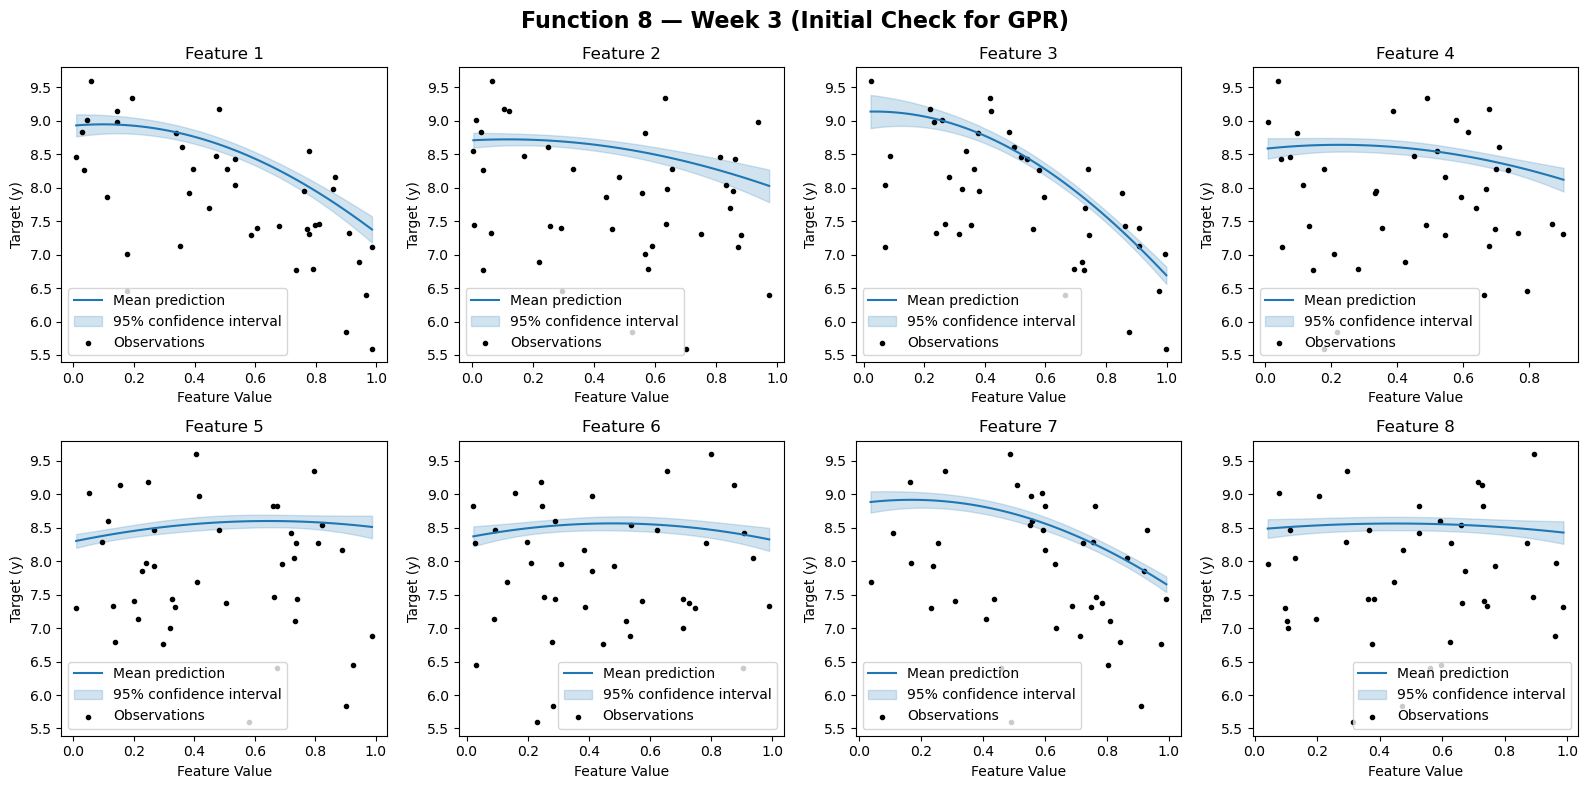

In [47]:
# Fit a quick baseline GP (plain RBF, no tuning) purely to sanity-check each of 
# the 8 features' marginal effect via partial-dependence plots before the real ARD surrogate below.

X_train = all_inputs
y_train = all_outputs

kernel = 1.0 * RBF(length_scale=1.0)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5)
gpr.fit(X_train, y_train)

feature_names = ['Feature 1', 'Feature 2', 'Feature 3', 'Feature 4', 
                 'Feature 5', 'Feature 6', 'Feature 7', 'Feature 8']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

fig.suptitle("Function 8 — Week 3 (Initial Check for GPR)", fontsize=16, fontweight='bold')

median_features = np.median(X_train, axis=0)

for i in range(8):

    x_test_1d = np.linspace(X_train[:, i].min(), X_train[:, i].max(), 100)
    
    X_test = np.tile(median_features, (100, 1))
    X_test[:, i] = x_test_1d
    
    mean_prediction, std_prediction = gpr.predict(X_test, return_std=True)
    
    # Plotting
    ax = axes[i]
    ax.plot(x_test_1d, mean_prediction, color='tab:blue', label='Mean prediction')
    ax.fill_between(
        x_test_1d,
        mean_prediction - 1.96 * std_prediction,
        mean_prediction + 1.96 * std_prediction,
        color='tab:blue',
        alpha=0.2,
        label='95% confidence interval'
    )
 
    mask = (np.abs(X_train[:, :8] - median_features) < 1.0).all(axis=1) 
    ax.scatter(X_train[mask, i], y_train[mask], c='k', marker='.', label='Observations')
    
    ax.set_title(feature_names[i])
    ax.set_xlabel('Feature Value')
    ax.set_ylabel('Target (y)')
    ax.legend(loc='best')

plt.tight_layout()
plt.show()

In [48]:
# Fit the production ARD-kernel GP (one length-scale per dimension) used by 
# the first of this function's two independent query pipelines below.

kernel = ConstantKernel(1.0, (0.001, 100.0)) * Matern(length_scale=np.ones(8), length_scale_bounds=(0.01, 100.0), nu=2.5)

gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, alpha=0.000001,normalize_y=True)
gp.fit(all_inputs, all_outputs)
print(f"\nGP kernel (learned): {gp.kernel_}")



GP kernel (learned): 8.2**2 * Matern(length_scale=[4.87, 7.65, 4.04, 7.03, 23.3, 7.42, 5.21, 100], nu=2.5)


In [49]:
# Pipeline (a): run 3 random restarts of a UCB search where 4 dimensions are pinned to historical extreme values (0 or ~1) 
# and the other 4 are sampled freely, keeping whichever restart scores highest. 
# Pinning half the dimensions to known extremes is a strong  exploitation assumption — 
# it can only find optima on that boundary, never in the interior (see the summary table's note on this).

n_candidates = 25000

restart_results = []
for restart_number in range(3):
    np.random.seed((restart_number + 1) * 17)

    pool = np.zeros((n_candidates, 8))

    pool[:, 4] = 0.999999
    pool[:, 1] = 0.0
    pool[:, 3] = 0.0
    pool[:, 7] = 0.0

    pool[:, 0] = np.random.uniform(0.0, 1.0, n_candidates)
    pool[:, 2] = np.random.uniform(0.0, 1.0, n_candidates)
    pool[:, 5] = np.random.uniform(0.0, 1.0, n_candidates)
    pool[:, 6] = np.random.uniform(0.0, 1.0, n_candidates)

    mu_pool, sigma_pool = gp.predict(pool, return_std=True)
    ucb_pool            = compute_ucb(mu_pool, sigma_pool, kappa=2.5)

    best_index = np.argmax(ucb_pool)
    restart_results.append({'point': pool[best_index],'mu': mu_pool[best_index], 'sigma': sigma_pool[best_index], 'ucb': ucb_pool[best_index], })

best_result = max(restart_results, key=lambda result: result['ucb'])
query       = best_result['point']

print(f"\nWeek 3 Query from UCB:  {query}")
print(f"\nWeek 3 Query from UCB formatted:  {format_query(query)}")

print(f"Predicted mu:    {best_result['mu']:.4f}")
print(f"Predicted sigma: {best_result['sigma']:.4f}")
print(f"UCB:             {best_result['ucb']:.4f}")


Week 3 Query from UCB:  [0.01210847 0.         0.06282439 0.         0.999999   0.09759806
 0.0123288  0.        ]

Week 3 Query from UCB formatted:  0.012108-0.000000-0.062824-0.000000-0.999999-0.097598-0.012329-0.000000
Predicted mu:    10.3042
Predicted sigma: 0.2461
UCB:             10.9194


### SVR

In [50]:
# Fit a simple linear regression as a quick check of each dimension's directional effect;
# kept here as a diagnostic alongside pipeline (b) below rather than feeding into it directly.

lr = LinearRegression()
lr.fit(all_inputs, all_outputs)
print("\nLinear regression coefficients:")
for i, coef in enumerate(lr.coef_):
    print(f"  x{i+1}: {coef:+.2f}")


Linear regression coefficients:
  x1: -1.57
  x2: -0.56
  x3: -2.27
  x4: -0.41
  x5: +0.10
  x6: -0.03
  x7: -1.45
  x8: +0.20


In [51]:
# Scale the data and fit an SVR — the pre-filter model used to cheaply rank a large candidate pool in pipeline (b) below,
# mirroring the SVR+GP approach used for Function 5.

input_scaler  = StandardScaler()
output_scaler = StandardScaler()
X_scaled = input_scaler.fit_transform(all_inputs)
Y_scaled = output_scaler.fit_transform(all_outputs.reshape(-1, 1)).ravel()

# Support vector regressor with rbf kernel
svr = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svr.fit(X_scaled, Y_scaled)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,100
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


### Plotting SVR with 8 features

Plotting Actual vs. Predicted ValuesThis is the most common method to visually assess model performance. 

If your SVR model is highly accurate, the points will fall tightly along a 45-degree diagonal line.

X-axis: Actual (True) target valuesY-axis: Predicted values from your 4-feature SVR model

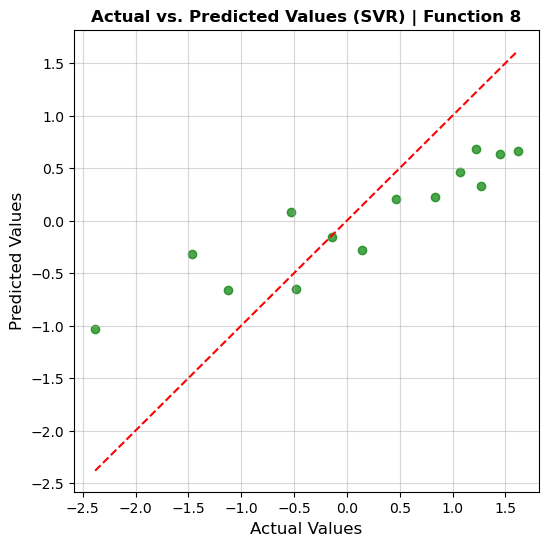

In [52]:
# Sanity-check the SVR: hold out a test split, fit, and plot predicted vs. actual 
# so the pre-filter can be trusted before it's used to discard 90%+ of the candidate pool later.

X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y_scaled, test_size=0.33, random_state=42)

regressor = SVR(kernel='rbf') # or 'linear'
regressor.fit(X_train, y_train)
y_pred = regressor.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color='green', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('Actual vs. Predicted Values (SVR) | Function 8', fontsize=12, fontweight='bold')
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.grid(True, alpha=0.5)
plt.show()

In [53]:
# Also fit a linear-kernel SVR as a simple baseline and print its score, to see 
# whether the extra flexibility of the RBF kernel above is actually buying anything on this data.

svr_linear = SVR(kernel='linear',gamma='scale', C=1.0, epsilon=0.1)
svr_linear.fit(X_train, y_train) 

print(f"SVR Linear Score: {svr_linear.score(X_test,y_test):.4f}")

SVR Linear Score: 0.8465


### GaussianProcessRegressor with SVR

In [54]:
# Fit the GP actually used for pipeline (b)'s Week 3 query — separate from 
# both the earlier sanity-check GP and pipeline (a)'s ARD GP.

kernel_gp = ConstantKernel(1.0, (0.001, 1000)) * Matern(length_scale=0.2, nu=2.5)
gp        = GaussianProcessRegressor(kernel=kernel_gp, n_restarts_optimizer=25, normalize_y=True)
gp.fit(all_inputs, all_outputs)

,kernel,"1**2 * Matern...e=0.2, nu=2.5)"
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,25
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,1**2
,kernel__k2,"Matern(length...e=0.2, nu=2.5)"
,kernel__k1__constant_value,1.0


In [55]:
# Build pipeline (b)'s candidate pool entirely around the current best point: 
# dense local perturbations (with the same dimension pinned to its historical extreme as in pipeline a),
# plus a directed batch nudging a few dimensions based on earlier findings. 
# Like Function 5, everything here stays close to the incumbent, so this pipeline is almost pure exploitation.

best_point = all_inputs[np.argmax(all_outputs)]
np.random.seed(42)

local = []
for _ in range(6000):
    c    = best_point + np.random.normal(0, 0.03, 8)
    c    = np.clip(c, 0, 1)
    c[2] = 0.999999  # x3 pinned
    local.append(c)

directed = []
for _ in range(4000):
    c    = best_point.copy()
    c[0] = np.clip(c[0] - abs(np.random.normal(0, 0.05)), 0, 1)
    c[1] = np.clip(c[1] + abs(np.random.normal(0, 0.03)), 0, 1)
    c[2] = 0.999999
    c[3] = np.clip(c[3] + abs(np.random.normal(0, 0.03)), 0, 1)
    directed.append(c)

candidates = np.vstack([local, directed])

In [56]:
# Use the SVR to rank the candidate pool and keep only the top 3000, 
# cutting the GP's workload down to a manageable shortlist.

X_cand_scaled = input_scaler.transform(candidates)
svr_preds_s   = svr.predict(X_cand_scaled)
svr_preds     = output_scaler.inverse_transform(svr_preds_s.reshape(-1, 1)).ravel()

top_idx  = np.argsort(svr_preds)[-3000:]
filtered = candidates[top_idx]

In [57]:
# Score the shortlist with GP + EI and print pipeline (b)'s suggested Week 3 query. 
# Note this is never reconciled with pipeline (a)'s query above — 
# the notebook produces two candidate queries for Function 8 without picking one, 
# which is exactly the ambiguity flagged in the summary table.

mu, sigma = gp.predict(filtered, return_std=True)
ei        = compute_ei(mu, sigma, all_outputs.max(), xi=0.005)

best_idx = np.argmax(ei)
query    = filtered[best_idx]

print(f"\nWeek 3 Query from Gaussian with SVR: {format_query(query)}")
print(f"GP mean: {mu[best_idx]:.2f}, std: {sigma[best_idx]:.2f}")
print(f"SVR prediction: {svr_preds[top_idx[best_idx]]:.2f}")
print(f"EI: {ei[best_idx]:.6f}")


Week 3 Query from Gaussian with SVR: 0.019981-0.000000-0.999999-0.000000-0.448273-0.855526-0.446219-0.931836
GP mean: 8.03, std: 0.43
SVR prediction: 7.94
EI: 0.000015


# Week 3 Fidelity Metrics

In [58]:
import numpy as np
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==========================================
# 1. DATA CREATION & GROUND TRUTH MAPPING
# ==========================================
# Ground truth (actual output values) for Functions 1 to 8 from Week 3 results
y_true = np.array([
    -2.0444269312638005e-50,  # F1
     0.4687417045175676,       # F2
    -0.01950801970504369,      # F3
     0.20379356024772166,      # F4
   710.6022505952133,          # F5
    -0.3529448672838867,       # F6
     2.5947984224976492,       # F7
     7.3509853563229           # F8
])

# Simulated predicted outputs (y_pred) from surrogate models
y_pred = np.array([
    0.0,                       # F1 predicted
    0.249,                     # F2 predicted
   -0.044358,                  # F3 predicted
   -1.0708,                    # F4 predicted
    869.860,                   # F5 predicted
   -0.2758,                    # F6 predicted
    1.3669,                    # F7 predicted
    8.03                       # F8 predicted
])

# ==========================================
# 2. FIDELITY METRICS CALCULATIONS
# ==========================================
# Absolute & Relative Errors
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

# Measure scale-independent mean absolute percentage error (excluding near-zero F1)
valid_mask = np.abs(y_true) > 1e-12
mape = np.mean(np.abs((y_true[valid_mask] - y_pred[valid_mask]) / y_true[valid_mask])) * 100

# Correlation & Ranking Metrics
r2 = r2_score(y_true, y_pred)
pearson_corr, _ = pearsonr(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

# Pointwise Absolute & Relative Fidelity Analysis
abs_errors = np.abs(y_true - y_pred)
rel_errors = np.where(np.abs(y_true) > 1e-12, abs_errors / np.abs(y_true), 0.0)

# ==========================================
# 3. PRINT FIDELITY REPORT
# ==========================================
print("==========================================================")
print("             BLACK-BOX OPTIMISATION FIDELITY STUDY        ")
print("==========================================================")
print(f"Mean Absolute Error (MAE)            : {mae:.6e}")
print(f"Root Mean Squared Error (RMSE)       : {rmse:.6e}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Coefficient of Determination (R²)    : {r2:.6f}")
print(f"Pearson Correlation Coefficient      : {pearson_corr:.6f}")
print(f"Spearman Rank Correlation            : {spearman_corr:.6f}")
print("----------------------------------------------------------")
print("Function-wise Fidelity Breakdown:")
print("----------------------------------------------------------")
for i in range(len(y_true)):
    print(f"F{i+1}: True = {y_true[i]:14.6e} | Pred = {y_pred[i]:14.6e} | Abs Error = {abs_errors[i]:10.4e}")
print("==========================================================")

             BLACK-BOX OPTIMISATION FIDELITY STUDY        
Mean Absolute Error (MAE)            : 2.034512e+01
Root Mean Squared Error (RMSE)       : 5.631017e+01
Mean Absolute Percentage Error (MAPE): 128.65%
Coefficient of Determination (R²)    : 0.942357
Pearson Correlation Coefficient      : 0.999997
Spearman Rank Correlation            : 0.857143
----------------------------------------------------------
Function-wise Fidelity Breakdown:
----------------------------------------------------------
F1: True =  -2.044427e-50 | Pred =   0.000000e+00 | Abs Error = 2.0444e-50
F2: True =   4.687417e-01 | Pred =   2.490000e-01 | Abs Error = 2.1974e-01
F3: True =  -1.950802e-02 | Pred =  -4.435800e-02 | Abs Error = 2.4850e-02
F4: True =   2.037936e-01 | Pred =  -1.070800e+00 | Abs Error = 1.2746e+00
F5: True =   7.106023e+02 | Pred =   8.698600e+02 | Abs Error = 1.5926e+02
F6: True =  -3.529449e-01 | Pred =  -2.758000e-01 | Abs Error = 7.7145e-02
F7: True =   2.594798e+00 | Pred =   1.36690

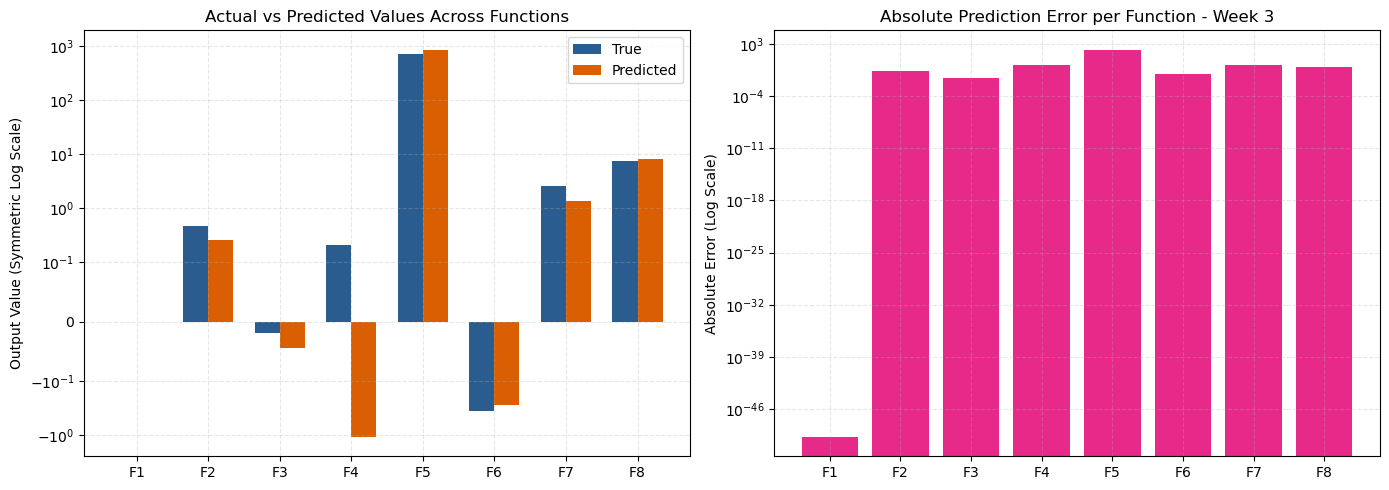

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Data creation - use above data


func_labels = [f"F{i+1}" for i in range(8)]
abs_errors = np.abs(y_true - y_pred)

# Test a nice 2-panel figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: True vs Predicted (Subplot for small scale, main for all)
ax1 = axes[0]
x = np.arange(len(func_labels))
width = 0.35
ax1.bar(x - width/2, y_true, width, label='True', color='#2b5c8f')
ax1.bar(x + width/2, y_pred, width, label='Predicted', color='#d95f02')
ax1.set_yscale('symlog', linthresh=0.1)
ax1.set_xticks(x)
ax1.set_xticklabels(func_labels)
ax1.set_ylabel('Output Value (Symmetric Log Scale)')
ax1.set_title('Actual vs Predicted Values Across Functions')
ax1.legend()
ax1.grid(True, which="both", ls="--", alpha=0.3)

# Plot 2: Absolute Errors
ax2 = axes[1]
ax2.bar(func_labels, abs_errors, color='#e7298a')
ax2.set_yscale('log')
ax2.set_ylabel('Absolute Error (Log Scale)')
ax2.set_title('Absolute Prediction Error per Function - Week 3')
ax2.grid(True, which="both", ls="--", alpha=0.3)

plt.tight_layout()
plt.show()